# Log-Normal Distribution Fitting via SPY Option Chains

Fits a **2-parameter log-normal law** for the terminal SPY price $S_T$ using call and put mid-prices at three separate DTE horizons:

- **14 DTE** — ~2-week expiry
- **30 DTE** — ~1-month expiry  
- **45 DTE** — ~1.5-month expiry

Each fit uses only options near that expiry (calls **and** puts) and a CVXPY linearized least-squares step to correct the realized (μ, σ) guess toward market prices.

**Section 4** runs a repeated-sample test over historical windows: for a chosen DTE, we sample many chain dates, fit the log-normal, compute the predicted μ and covariance matrix for (underlying, ATM call, ATM put), then compare to the realized outcomes.

---
## 0. Configuration

In [95]:
# ── Change these ──────────────────────────────────────────────────────────────
ASSET = "SPY"

# Chain date to use for Sections 1–3 (fits + distribution plots).
# Must be far enough in the past that we have realized prices:
#   at least 45 calendar days before last available SPY close.
# Set to None to auto-pick (most recent date with ≥45 days of realized data).
CHAIN_DATE = None   # e.g. "2026-01-12"  or None for auto

# DTE targets for the three fits
DTE_14  = 14
DTE_30  = 30
DTE_45  = 45

# Section 4: repeated-sample test
TEST_DTE       = 30          # which DTE distribution to test (14, 30, or 45)
N_SAMPLES      = 60          # how many historical chain dates to sample
MIN_DAYS_BACK  = 50          # chain date must be at least this many calendar days before last close
LOOKBACK_DAYS  = 21          # trading-day window for realized vol / mu guess
N_SCENARIOS    = 50_000      # Monte Carlo draws for predicted distribution
N_PARAM_DRAWS  = 2_000       # parameter-uncertainty draws
R_ANN          = 0.05        # risk-free rate (annualized)

---
## 1. Setup and data load

In [96]:
%matplotlib inline
import sys, os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
from scipy.stats import norm, lognorm
from scipy.optimize import brentq

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config import OPTION_CHAINS_DIR, SPY_DAILY_FILE, RAW_DIR
from data.forecasts import load_chain_for_expiry, _bs_call_price, _bs_put_price

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})
print("Imports OK")

Imports OK


In [97]:
# Load SPY price series
price_file = SPY_DAILY_FILE if ASSET == "SPY" else RAW_DIR / f"{ASSET.lower()}_daily.parquet"
prices = pd.read_parquet(price_file)
prices.index = pd.to_datetime(prices.index).tz_localize(None).normalize()
prices = prices.sort_index()
prices["log_ret"] = np.log(prices["close"] / prices["close"].shift(1))

last_close_date = prices.index.max()
print(f"SPY price range: {prices.index.min().date()} → {last_close_date.date()}")
print(f"Last close: ${prices['close'].iloc[-1]:.2f}")

SPY price range: 2020-01-02 → 2026-02-26
Last close: $689.30


In [98]:
# Discover chain dates and pick the one for fits (must have ≥45 days of realized data)
chain_dir = OPTION_CHAINS_DIR if ASSET == "SPY" else OPTION_CHAINS_DIR / ASSET
all_chain_files = sorted(os.listdir(chain_dir))
chain_dates_all = sorted({
    f.replace("calls_", "").replace("puts_", "").replace(".parquet", "")
    for f in all_chain_files
    if (f.startswith("calls_") or f.startswith("puts_")) and f.endswith(".parquet")
})

MIN_REALIZED_DAYS = 45  # need at least 45 calendar days of realized history
eligible = [
    d for d in chain_dates_all
    if (last_close_date - pd.Timestamp(d)).days >= MIN_REALIZED_DAYS
]

if CHAIN_DATE is not None:
    fit_date = CHAIN_DATE
    assert fit_date in eligible, f"{fit_date} not eligible (need ≥45 days realized data)"
else:
    fit_date = eligible[-1]  # most recent date with ≥45 days of realized data

fit_ts = pd.Timestamp(fit_date)
idx_fit = prices.index.get_indexer([fit_ts], method="ffill")[0]
spot = float(prices.iloc[idx_fit]["close"])

recent_rets = prices.loc[prices.index <= fit_ts, "log_ret"].iloc[-LOOKBACK_DAYS:].dropna()
mu_guess_ann = float(recent_rets.mean() * 252) if len(recent_rets) else 0.0
sigma_guess_ann = .2
#float(recent_rets.std() * np.sqrt(252)) if len(recent_rets) >= 2 else 0.15
sigma_guess_ann = max(sigma_guess_ann, 1e-4)

days_realized = (last_close_date - fit_ts).days
print(f"Fit date (as-of): {fit_date}")
print(f"Spot on fit date: ${spot:.2f}")
print(f"Realized data available: {days_realized} calendar days after fit date")
print(f"Realized guess: mu_ann={mu_guess_ann:+.2%},  sigma_ann={sigma_guess_ann:.2%}")
print(f"Total eligible chain dates: {len(eligible)}")

Fit date (as-of): 2026-01-12
Spot on fit date: $695.16
Realized data available: 45 calendar days after fit date
Realized guess: mu_ann=+13.17%,  sigma_ann=20.00%
Total eligible chain dates: 488


---
## 2. Core helpers: log-normal pricing and fitting

The log-normal model for $S_T$ has two annualized parameters $(\mu_{\text{ann}}, \sigma_{\text{ann}})$:

$$\log S_T \sim \mathcal{N}\!\left(\log S_0 + \left(\mu - \tfrac{1}{2}\sigma^2\right)T,\; \sigma^2 T\right)$$

Options are priced in closed form (Black–Scholes style). We fit $(\mu, \sigma)$ to market mids using one linearized CVXPY least-squares step from the realized guess.

In [99]:
def lognormal_price(K, is_call, mu_ann, sigma_ann, spot_0, T, r=R_ANN):
    """Closed-form log-normal option price (Black-Scholes with arbitrary drift)."""
    sigma_ann = max(float(sigma_ann), 1e-4)
    sigma_t   = max(sigma_ann * np.sqrt(T), 1e-6)
    m  = np.log(spot_0) + (float(mu_ann) - 0.5 * sigma_ann**2) * T
    d2 = (m - np.log(K)) / sigma_t
    d1 = d2 + sigma_t
    mean_st = np.exp(m + 0.5 * sigma_t**2)
    if is_call:
        payoff = mean_st * norm.cdf(d1) - K * norm.cdf(d2)
    else:
        payoff = K * norm.cdf(-d2) - mean_st * norm.cdf(-d1)
    return np.exp(-r * T) * payoff


def lognormal_price_vec(df, mu_ann, sigma_ann, spot_0, T, r=R_ANN):
    """Price a DataFrame of options (columns: strike, type) under log-normal."""
    return np.array([
        lognormal_price(row["strike"], row["type"] == "call",
                        mu_ann, sigma_ann, spot_0, T, r)
        for _, row in df.iterrows()
    ])


def fit_lognormal(option_df, spot_0, T, r=R_ANN,
                  mu_guess=None, sigma_guess=None,
                  recent_log_rets=None):
    """
    Fit (mu_ann, sigma_ann) to option_df market mids via one linearized CVXPY QP step.

    Returns dict with keys: mu_guess, sigma_guess, mu_fit, sigma_fit,
                            param_cov, train_rmse, holdout_rmse, option_df.
    """
    if mu_guess is None:
        mu_guess = float(recent_log_rets.mean() * 252) if recent_log_rets is not None and len(recent_log_rets) else 0.0
    if sigma_guess is None:
        sigma_guess = max(float(recent_log_rets.std() * np.sqrt(252)) if recent_log_rets is not None and len(recent_log_rets) >= 2 else 0.15, 1e-4)

    df = option_df.sort_values(["type", "strike"]).reset_index(drop=True).copy()
    holdout_mask = (np.arange(len(df)) % 5) == 0
    train_df = df.loc[~holdout_mask]

    bump_mu    = max(0.01, 0.25 * max(abs(mu_guess), 0.01))
    bump_sigma = max(0.01, 0.10 * sigma_guess)

    base  = lognormal_price_vec(train_df, mu_guess, sigma_guess, spot_0, T, r)
    jac   = np.column_stack([
        (lognormal_price_vec(train_df, mu_guess + bump_mu, sigma_guess, spot_0, T, r) - base) / bump_mu,
        (lognormal_price_vec(train_df, mu_guess, sigma_guess + bump_sigma, spot_0, T, r) - base) / bump_sigma,
    ])

    step = cp.Variable(2)
    prob = cp.Problem(
        cp.Minimize(cp.sum_squares(base + jac @ step - train_df["market_mid"].to_numpy())),
        [sigma_guess + step[1] >= 0.02]
    )
    prob.solve()
    sv = np.zeros(2) if step.value is None else np.asarray(step.value).reshape(-1)

    mu_fit    = mu_guess    + float(sv[0])
    sigma_fit = max(0.02,  sigma_guess + float(sv[1]))

    df["guess_price"] = lognormal_price_vec(df, mu_guess, sigma_guess, spot_0, T, r)
    df["fit_price"]   = lognormal_price_vec(df, mu_fit,   sigma_fit,   spot_0, T, r)

    def rmse(mask, col):
        return float(np.sqrt(((df.loc[mask, col] - df.loc[mask, "market_mid"]) ** 2).mean()))

    # Local parameter covariance (for sampling uncertainty)
    base_fit  = lognormal_price_vec(train_df, mu_fit, sigma_fit, spot_0, T, r)
    bm_f = max(0.01, 0.25 * max(abs(mu_fit), 0.01))
    bs_f = max(0.01, 0.10 * sigma_fit)
    jac_fit = np.column_stack([
        (lognormal_price_vec(train_df, mu_fit + bm_f, sigma_fit, spot_0, T, r) - base_fit) / bm_f,
        (lognormal_price_vec(train_df, mu_fit, sigma_fit + bs_f, spot_0, T, r) - base_fit) / bs_f,
    ])
    resid = train_df["market_mid"].to_numpy() - base_fit
    dof   = max(len(train_df) - 2, 1)
    mse   = float(np.sum(resid**2) / dof)
    param_cov = mse * np.linalg.pinv(jac_fit.T @ jac_fit)
    param_cov = np.nan_to_num(0.5 * (param_cov + param_cov.T), nan=0.0, posinf=0.0, neginf=0.0)

    return dict(
        mu_guess=mu_guess, sigma_guess=sigma_guess,
        mu_fit=mu_fit,     sigma_fit=sigma_fit,
        param_cov=param_cov,
        train_rmse_guess=rmse(~holdout_mask, "guess_price"),
        train_rmse_fit=rmse(~holdout_mask, "fit_price"),
        holdout_rmse_guess=rmse(holdout_mask, "guess_price"),
        holdout_rmse_fit=rmse(holdout_mask, "fit_price"),
        option_df=df, T=T, r=r, spot=spot_0,
    )


def to_per_share(mid, K, spot_0, is_call, r, T, tol=0.01):
    """Return per-share option mid, or NaN if bounds fail."""
    mid = float(mid)
    if not np.isfinite(mid) or mid <= 0:
        return np.nan
    if is_call:
        lb, ub = 0.0, spot_0
    else:
        lb, ub = max(0.0, K - spot_0), K * np.exp(-r * T)
    if lb - tol <= mid <= ub + tol:
        return mid
    if mid > 5.0 * ub and ub > 0:
        candidate = mid / 100.0
        if lb - tol <= candidate <= ub + tol:
            return candidate
    return np.nan


def load_options_for_dte(chain_date, target_dte, spot_0, r=R_ANN, min_mid=0.02, max_spread=0.80):
    """
    Load calls + puts closest to target_dte, filter to valid per-share mids.
    Returns (option_df, expiry_str, T).
    """
    ref = pd.Timestamp(chain_date)
    meta = pd.read_parquet(chain_dir / f"calls_{chain_date}.parquet")
    meta.columns = [c.replace("impliedVolatility", "impl_vol").lower() for c in meta.columns]
    expiry_arg = None
    if "expiry" in meta.columns:
        expiries  = sorted(meta["expiry"].dropna().unique())
        dte_list  = [(e, (pd.Timestamp(e) - ref).days) for e in expiries
                     if (pd.Timestamp(e) - ref).days > 0]
        if dte_list:
            expiry_arg = min(dte_list, key=lambda x: abs(x[1] - target_dte))[0]

    calls, puts, expiry_used = load_chain_for_expiry(
        chain_date=chain_date, expiry=expiry_arg, underlying=ASSET,
        min_mid=min_mid, max_spread=max_spread,
    )
    if len(calls) == 0 or len(puts) == 0:
        raise ValueError(f"No valid calls/puts on {chain_date} near DTE {target_dte}")

    exp_ts = pd.Timestamp(expiry_used)
    T      = max((exp_ts - ref).days / 365.0, 1e-4)

    rows = []
    for is_call, df_src in [(True, calls), (False, puts)]:
        for _, row in df_src.iterrows():
            K   = float(row["strike"])
            raw = float(row.get("mid", (row.get("bid", 0.0) + row.get("ask", 0.0)) / 2.0))
            mid = to_per_share(raw, K, spot_0, is_call, r, T)
            if np.isfinite(mid):
                rows.append({"strike": K, "type": "call" if is_call else "put", "market_mid": mid})

    if len(rows) < 10:
        raise ValueError(f"Too few valid options after filter on {chain_date} DTE~{target_dte}")

    return pd.DataFrame(rows), expiry_used, T


# ── ATM implied-vol baseline ─────────────────────────────────────────────────

def _bs_call(S, K, T, r, sigma):
    """Standard Black-Scholes call price (risk-neutral drift = r)."""
    sigma = max(sigma, 1e-6)
    sqrt_T = max(np.sqrt(T), 1e-6)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt_T)
    d2 = d1 - sigma * sqrt_T
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def compute_atm_iv(option_df, spot_0, T, r=R_ANN, iv_lo=1e-4, iv_hi=5.0):
    """
    Compute ATM implied volatility from the option chain.

    Strategy:
      1. Find the call whose strike is closest to spot_0.
      2. Invert Black-Scholes (risk-neutral, drift = r) using Brent's method.
      3. If inversion fails, fall back to the median IV across all OTM calls.

    Returns (sigma_iv, strike_used).
    """
    calls = option_df[option_df["type"] == "call"].copy()
    if calls.empty:
        raise ValueError("No calls in option_df for IV computation.")

    calls = calls.assign(_dist=(calls["strike"] - spot_0).abs())
    atm_row = calls.loc[calls["_dist"].idxmin()]
    K_atm = float(atm_row["strike"])
    mid   = float(atm_row["market_mid"])

    def objective(sig):
        return _bs_call(spot_0, K_atm, T, r, sig) - mid

    try:
        lo_val, hi_val = objective(iv_lo), objective(iv_hi)
        if lo_val * hi_val > 0:
            # Bracket not valid — fall back to median across all calls
            ivs = []
            for _, row in calls.iterrows():
                try:
                    iv = brentq(
                        lambda s: _bs_call(spot_0, row["strike"], T, r, s) - row["market_mid"],
                        iv_lo, iv_hi, xtol=1e-6
                    )
                    ivs.append(iv)
                except Exception:
                    pass
            if not ivs:
                raise ValueError("IV inversion failed on all calls.")
            return float(np.median(ivs)), K_atm

        sigma_iv = brentq(objective, iv_lo, iv_hi, xtol=1e-6)
        return float(sigma_iv), K_atm
    except Exception as e:
        raise ValueError(f"ATM IV inversion failed (K={K_atm:.1f}, mid={mid:.4f}): {e}")


def iv_lognormal_pdf(S_grid, spot_0, sigma_iv, T, r=R_ANN):
    """Log-normal PDF under risk-neutral measure using σ = ATM IV, drift = r."""
    sig_t = max(sigma_iv * np.sqrt(T), 1e-6)
    m     = np.log(spot_0) + (r - 0.5 * sigma_iv**2) * T
    return lognorm.pdf(S_grid, s=sig_t, scale=np.exp(m))


print("Helpers defined.")

Helpers defined.


---
## 2b. Gauss-Newton / DNLP Fitting via Iterative CVXPY QP Subproblems

The original `fit_lognormal` linearizes the pricing map **once** from the realized-vol guess — a single Newton step. That works well only when the guess is close to the market-implied optimum.

**Gauss-Newton (GN)** iterates this idea: at each step we linearize around the *current* estimate, solve a constrained CVXPY quadratic programme, then update. This turns the non-convex nonlinear least-squares problem into a sequence of **disciplined convex QPs** — a principled *Disciplined Non-Linear Programming (DNLP)* decomposition:

$$
\underbrace{\min_{\mu,\sigma}\; \tfrac{1}{2}\sum_i \bigl[p_i(\mu,\sigma) - m_i\bigr]^2}_{\text{nonlinear NLS}}
\;\;\Longrightarrow\;\;
\underbrace{\min_{\delta}\; \tfrac{1}{2}\|r^{(k)} + J^{(k)}\delta\|^2 + \tfrac{\lambda}{2}\|\delta\|^2}_{\text{convex CVXPY QP at iteration }k}
$$

The Levenberg-Marquardt damping term $\frac{\lambda}{2}\|\delta\|^2$ ensures each QP has a unique solution and automatically interpolates between gradient descent (large $\lambda$) and pure GN (small $\lambda$).  $\lambda$ is reduced each iteration as the residual improves (trust-region-style adaptive damping).

In [100]:
def _numerical_jacobian(df, mu, sigma, spot_0, T, r):
    """Numerical Jacobian of lognormal_price_vec w.r.t. (mu, sigma)."""
    h_mu    = max(1e-4, 0.01 * max(abs(mu), 0.01))
    h_sigma = max(1e-4, 0.01 * sigma)
    base = lognormal_price_vec(df, mu, sigma, spot_0, T, r)
    d_mu    = (lognormal_price_vec(df, mu + h_mu,    sigma,         spot_0, T, r) - base) / h_mu
    d_sigma = (lognormal_price_vec(df, mu,           sigma + h_sigma, spot_0, T, r) - base) / h_sigma
    return np.column_stack([d_mu, d_sigma]), base


def fit_lognormal_gn(option_df, spot_0, T, r=R_ANN,
                     mu_guess=None, sigma_guess=None,
                     recent_log_rets=None,
                     max_iter=25, tol=1e-7,
                     lm_lambda_init=1e-2, lm_shrink=0.5, lm_grow=2.0):
    """
    Gauss-Newton (Levenberg-Marquardt) iterative log-normal fit.

    Each iteration solves a CVXPY QP subproblem:
        min  ||r + J*delta||^2 + lambda * ||delta||^2
        s.t. sigma + delta_sigma >= 0.02

    lambda adapts: shrinks when residual improves, grows when it doesn't.
    Returns same dict as fit_lognormal plus 'gn_history' (list of per-iter stats).
    """
    if mu_guess is None:
        mu_guess = float(recent_log_rets.mean() * 252) if recent_log_rets is not None and len(recent_log_rets) else 0.0
    if sigma_guess is None:
        sigma_guess = max(float(recent_log_rets.std() * np.sqrt(252)) if recent_log_rets is not None and len(recent_log_rets) >= 2 else 0.15, 1e-4)

    df = option_df.sort_values(["type", "strike"]).reset_index(drop=True).copy()
    holdout_mask = (np.arange(len(df)) % 5) == 0
    train_df     = df.loc[~holdout_mask].reset_index(drop=True)
    mids_train   = train_df["market_mid"].to_numpy()

    mu    = float(mu_guess)
    sigma = max(float(sigma_guess), 0.02)
    lam   = lm_lambda_init

    history = []
    prev_sse = np.inf

    for it in range(max_iter):
        J, prices_cur = _numerical_jacobian(train_df, mu, sigma, spot_0, T, r)
        residuals = mids_train - prices_cur
        sse_cur   = float(np.dot(residuals, residuals))

        history.append({"iter": it, "mu": mu, "sigma": sigma,
                         "sse": sse_cur, "lambda": lam})

        # ── CVXPY QP subproblem (DNLP step) ──────────────────────────────────
        delta = cp.Variable(2)
        lm_reg = lam * cp.sum_squares(delta)          # Levenberg-Marquardt damping
        objective  = cp.Minimize(cp.sum_squares(residuals - J @ delta) + lm_reg)
        constraint = [sigma + delta[1] >= 0.02]
        cp.Problem(objective, constraint).solve(warm_start=True)

        if delta.value is None:                        # solver failed; bail out
            break

        dv = np.asarray(delta.value).reshape(-1)
        mu_new    = mu    + float(dv[0])
        sigma_new = max(0.02, sigma + float(dv[1]))

        _, prices_new = _numerical_jacobian(train_df, mu_new, sigma_new, spot_0, T, r)
        sse_new = float(np.sum((mids_train - prices_new) ** 2))

        if sse_new < sse_cur:
            # Accept step and reduce damping (more Newton-like)
            mu, sigma = mu_new, sigma_new
            lam = max(lam * lm_shrink, 1e-8)
            if abs(sse_cur - sse_new) / max(sse_cur, 1e-12) < tol:
                break
        else:
            # Reject step; increase damping (more gradient-descent-like)
            lam = min(lam * lm_grow, 1e3)

        prev_sse = sse_cur

    # ── Final annotation of full DataFrame ───────────────────────────────────
    df["guess_price"] = lognormal_price_vec(df, mu_guess, sigma_guess, spot_0, T, r)
    df["fit_price_1step"] = lognormal_price_vec(df, *[
        v for v in [mu_guess, sigma_guess]    # reuse single-step for comparison
    ], spot_0, T, r)
    df["fit_price_gn"] = lognormal_price_vec(df, mu, sigma, spot_0, T, r)

    def rmse(mask, col):
        return float(np.sqrt(((df.loc[mask, col] - df.loc[mask, "market_mid"]) ** 2).mean()))

    # Parameter covariance at converged point
    J_final, prices_final = _numerical_jacobian(train_df, mu, sigma, spot_0, T, r)
    resid_final = mids_train - prices_final
    dof         = max(len(train_df) - 2, 1)
    mse_final   = float(np.dot(resid_final, resid_final) / dof)
    JTJ         = J_final.T @ J_final
    param_cov   = mse_final * np.linalg.pinv(JTJ)
    param_cov   = np.nan_to_num(0.5 * (param_cov + param_cov.T),
                                nan=0.0, posinf=0.0, neginf=0.0)

    n_iter = len(history)
    print(f"  GN converged in {n_iter} iterations  "
          f"μ={mu:+.4f}  σ={sigma:.4f}  "
          f"train RMSE={rmse(~holdout_mask, 'fit_price_gn'):.4f}  "
          f"holdout RMSE={rmse(holdout_mask, 'fit_price_gn'):.4f}")

    return dict(
        mu_guess=mu_guess, sigma_guess=sigma_guess,
        mu_fit=mu,         sigma_fit=sigma,
        param_cov=param_cov,
        train_rmse_guess   =rmse(~holdout_mask, "guess_price"),
        train_rmse_fit     =rmse(~holdout_mask, "fit_price_gn"),
        holdout_rmse_guess =rmse( holdout_mask, "guess_price"),
        holdout_rmse_fit   =rmse( holdout_mask, "fit_price_gn"),
        option_df=df, T=T, r=r, spot=spot_0,
        gn_history=history,
    )


print("Gauss-Newton / DNLP fitter defined.")

Gauss-Newton / DNLP fitter defined.


---
## 3. Fit log-normal at 14 DTE, 30 DTE, and 45 DTE

For each DTE we:
1. Select the expiry closest to the target DTE from the chain on `fit_date`.
2. Filter calls and puts to valid per-share mid-prices.
3. Fit (μ_ann, σ_ann) via one linearized CVXPY least-squares step.
4. Report train / holdout RMSE and visualize the distribution and pricing error.

In [101]:
# ── Shared color palette (used by all plot cells) ────────────────────────────
COLORS = {"14d": "#2563eb", "30d": "#16a34a", "45d": "#dc2626"}

# ── Fit all three horizons ──────────────────────────────────────────────────
fits = {}
for label, target_dte in [("14d", DTE_14), ("30d", DTE_30), ("45d", DTE_45)]:
    try:
        opt_df, expiry_str, T_dte = load_options_for_dte(
            fit_date, target_dte, spot, r=R_ANN
        )
        result = fit_lognormal(
            opt_df, spot, T_dte, r=R_ANN,
            mu_guess=mu_guess_ann, sigma_guess=sigma_guess_ann,
        )
        result["expiry"] = expiry_str
        result["actual_dte"] = round(T_dte * 365)
        result["label"] = label
        fits[label] = result
        print(f"[{label}]  expiry={expiry_str}  DTE={result['actual_dte']}  "
              f"n_opts={len(opt_df)}")
        print(f"  Guess:  mu={result['mu_guess']:+.2%}  sigma={result['sigma_guess']:.2%}")
        print(f"  Fitted: mu={result['mu_fit']:+.2%}  sigma={result['sigma_fit']:.2%}")
        print(f"  RMSE  train  guess={result['train_rmse_guess']:.4f}  "
              f"fit={result['train_rmse_fit']:.4f}")
        print(f"  RMSE holdout guess={result['holdout_rmse_guess']:.4f}  "
              f"fit={result['holdout_rmse_fit']:.4f}")
        print()
    except Exception as e:
        print(f"[{label}] FAILED: {e}")

[14d]  expiry=2026-01-26  DTE=14  n_opts=34
  Guess:  mu=+13.17%  sigma=20.00%
  Fitted: mu=+5.63%  sigma=11.80%
  RMSE  train  guess=3.5619  fit=0.6586
  RMSE holdout guess=3.4252  fit=0.5346

[30d]  expiry=2026-02-13  DTE=32  n_opts=146
  Guess:  mu=+13.17%  sigma=20.00%
  Fitted: mu=+4.29%  sigma=13.63%
  RMSE  train  guess=5.5401  fit=1.1160
  RMSE holdout guess=5.7219  fit=1.2748

[45d]  expiry=2026-02-27  DTE=46  n_opts=225
  Guess:  mu=+13.17%  sigma=20.00%
  Fitted: mu=+4.12%  sigma=14.30%
  RMSE  train  guess=6.5266  fit=1.5344
  RMSE holdout guess=6.5584  fit=1.5649



### 3.1 Individual distribution + pricing-error plots

In [102]:
# # One 2-panel figure per DTE: (left) PDF of S_T, (right) model vs market mid
# COLORS = {"14d": "#2563eb", "30d": "#16a34a", "45d": "#dc2626"}

# for label, res in fits.items():
#     df_plot = res["option_df"]
#     T_  = res["T"]
#     s0  = res["spot"]

#     def _ln_params(mu_a, sig_a):
#         sig_t  = max(sig_a * np.sqrt(T_), 1e-6)
#         m      = np.log(s0) + (mu_a - 0.5 * sig_a**2) * T_
#         return sig_t, np.exp(m)

#     sg, sc = _ln_params(res["mu_guess"], res["sigma_guess"])
#     sf, scf = _ln_params(res["mu_fit"],   res["sigma_fit"])
#     S_grid = np.linspace(s0 * 0.70, s0 * 1.30, 600)

#     fig, axes = plt.subplots(1, 3, figsize=(15, 4))
#     col = COLORS[label]

#     # Left: terminal distribution
#     ax = axes[0]
#     ax.plot(S_grid, lognorm.pdf(S_grid, s=sg, scale=sc),
#             ls="--", lw=1.5, color="gray", label="Guess")
#     ax.plot(S_grid, lognorm.pdf(S_grid, s=sf, scale=scf),
#             lw=2.5, color=col, label="Fit")
#     ax.axvline(s0, color="black", ls=":", alpha=0.6, label=f"Spot={s0:.0f}")
#     ax.set_title(f"[{label}] Terminal $S_T$ distribution  (expiry {res['expiry']})")
#     ax.set_xlabel("$S_T$"); ax.set_ylabel("Density")
#     ax.legend(fontsize=9)

#     # Middle: model vs market (calls)
#     ax = axes[1]
#     for opt_type, marker, ec in [("call", "o", "#16a34a"), ("put", "^", "#dc2626")]:
#         sub = df_plot[df_plot["type"] == opt_type].sort_values("strike")
#         ax.scatter(sub["strike"], sub["market_mid"],
#                    s=14, color="black", marker=marker, zorder=3, alpha=0.7,
#                    label=f"Mkt {opt_type}" if opt_type == "call" else None)
#         ax.scatter(sub["strike"], sub["guess_price"],
#                    s=8, color="gray", marker=marker, alpha=0.4)
#         ax.scatter(sub["strike"], sub["fit_price"],
#                    s=8, color=col, marker=marker, alpha=0.6,
#                    label=f"Fit {opt_type}" if opt_type == "call" else None)
#     ax.axvline(s0, color="black", ls=":", alpha=0.5)
#     ax.set_title(f"[{label}] Model vs market mid ({len(df_plot)} options)")
#     ax.set_xlabel("Strike"); ax.set_ylabel("Option price")
#     ax.legend(fontsize=9)

#     # Right: error vs moneyness
#     ax = axes[2]
#     df_plot = df_plot.copy()
#     df_plot["error"]     = df_plot["fit_price"] - df_plot["market_mid"]
#     df_plot["moneyness"] = df_plot["strike"] / s0
#     for opt_type, ec in [("call", "#16a34a"), ("put", "#dc2626")]:
#         sub = df_plot[df_plot["type"] == opt_type]
#         ax.scatter(sub["moneyness"], sub["error"],
#                    s=20, color=ec, alpha=0.7, label=opt_type)
#     ax.axhline(0, color="black", ls="--", lw=1)
#     ax.set_title(f"[{label}] Pricing error vs moneyness")
#     ax.set_xlabel("Strike / Spot"); ax.set_ylabel("Fit price − Mkt mid ($)")
#     ax.legend(fontsize=9)

#     plt.tight_layout()
#     plt.show()

### 3.2 Overlay: all three fitted distributions

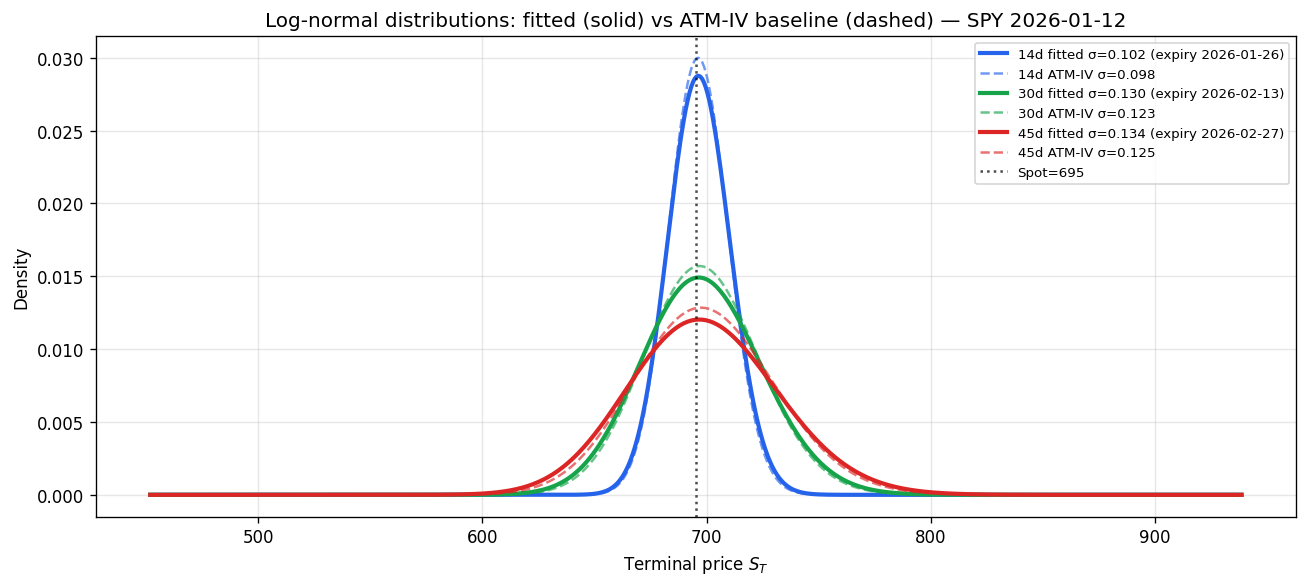

In [103]:
fig, ax = plt.subplots(figsize=(11, 5))

iv_cache = {}   # store ATM IVs for later use in section 3.5
_gn = globals().get('fits_gn', {})   # safe: may not exist yet on first run

for label, res in fits.items():
    T_  = res["T"]
    s0  = res["spot"]
    S_grid = np.linspace(s0 * 0.65, s0 * 1.35, 600)
    color  = COLORS[label]

    # ── Fitted log-normal (GN if available, else single-step) ──────────────
    mu_plot    = _gn[label]["mu_fit"]    if label in _gn else res["mu_fit"]
    sigma_plot = _gn[label]["sigma_fit"] if label in _gn else res["sigma_fit"]
    sig_t = max(sigma_plot * np.sqrt(T_), 1e-6)
    m     = np.log(s0) + (mu_plot - 0.5 * sigma_plot**2) * T_
    pdf_fit = lognorm.pdf(S_grid, s=sig_t, scale=np.exp(m))
    ax.plot(S_grid, pdf_fit, lw=2.5, color=color,
            label=f"{label} fitted σ={sigma_plot:.3f} (expiry {res['expiry']})")

    # ── ATM-IV baseline: risk-neutral log-normal with σ = ATM IV ───────────
    try:
        sigma_iv, K_atm = compute_atm_iv(res["option_df"], s0, T_, r=R_ANN)
        iv_cache[label] = {"sigma_iv": sigma_iv, "K_atm": K_atm, "T": T_, "spot": s0,
                           "expiry": res["expiry"]}
        pdf_iv = iv_lognormal_pdf(S_grid, s0, sigma_iv, T_, r=R_ANN)
        ax.plot(S_grid, pdf_iv, lw=1.5, color=color, ls="--", alpha=0.65,
                label=f"{label} ATM-IV σ={sigma_iv:.3f}")
    except Exception as e:
        print(f"  [{label}] ATM IV failed: {e}")

ax.axvline(spot, color="black", ls=":", lw=1.5, alpha=0.7, label=f"Spot={spot:.0f}")
ax.set_xlabel("Terminal price $S_T$")
ax.set_ylabel("Density")
ax.set_title(f"Log-normal distributions: fitted (solid) vs ATM-IV baseline (dashed) — {ASSET} {fit_date}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3.3 Gauss-Newton (DNLP) fit — all three DTE horizons

Run `fit_lognormal_gn` for each horizon and compare the holdout RMSE to the single linearized step.

In [104]:
fits_gn = {}
for label, target_dte in [("14d", DTE_14), ("30d", DTE_30), ("45d", DTE_45)]:
    try:
        opt_df, expiry_str, T = load_options_for_dte(
            fit_date, target_dte, spot, r=R_ANN
        )
        print(f"\n── {label}  expiry={expiry_str}  T={T:.4f}yr  n_options={len(opt_df)} ──")
        res = fit_lognormal_gn(
            opt_df, spot_0=spot, T=T, r=R_ANN,
            mu_guess=mu_guess_ann, sigma_guess=sigma_guess_ann,
            recent_log_rets=recent_rets,
        )
        fits_gn[label] = res
        fits_gn[label]["expiry"] = expiry_str

        # Cross-compare with single-step
        res_1step = fits[label]
        print(f"  1-step  holdout RMSE = {res_1step['holdout_rmse_fit']:.4f}   "
              f"μ={res_1step['mu_fit']:+.4f}  σ={res_1step['sigma_fit']:.4f}")
        improvement = (res_1step['holdout_rmse_fit'] - res['holdout_rmse_fit'])
        pct = 100 * improvement / max(res_1step['holdout_rmse_fit'], 1e-9)
        print(f"  GN      holdout RMSE = {res['holdout_rmse_fit']:.4f}   "
              f"μ={res['mu_fit']:+.4f}  σ={res['sigma_fit']:.4f}  "
              f"  Δ = {improvement:+.4f} ({pct:+.1f}%)")
    except Exception as e:
        print(f"{label}: {e}")


── 14d  expiry=2026-01-26  T=0.0384yr  n_options=34 ──
  GN converged in 6 iterations  μ=+0.0581  σ=0.1017  train RMSE=0.4581  holdout RMSE=0.3316
  1-step  holdout RMSE = 0.5346   μ=+0.0563  σ=0.1180
  GN      holdout RMSE = 0.3316   μ=+0.0581  σ=0.1017    Δ = +0.2030 (+38.0%)

── 30d  expiry=2026-02-13  T=0.0877yr  n_options=146 ──
  GN converged in 6 iterations  μ=+0.0462  σ=0.1296  train RMSE=1.0499  holdout RMSE=1.2740
  1-step  holdout RMSE = 1.2748   μ=+0.0429  σ=0.1363
  GN      holdout RMSE = 1.2740   μ=+0.0462  σ=0.1296    Δ = +0.0008 (+0.1%)

── 45d  expiry=2026-02-27  T=0.1260yr  n_options=225 ──
  GN converged in 6 iterations  μ=+0.0439  σ=0.1339  train RMSE=1.4381  holdout RMSE=1.4892
  1-step  holdout RMSE = 1.5649   μ=+0.0412  σ=0.1430
  GN      holdout RMSE = 1.4892   μ=+0.0439  σ=0.1339    Δ = +0.0757 (+4.8%)


### 3.4 GN convergence trajectories and final fit quality

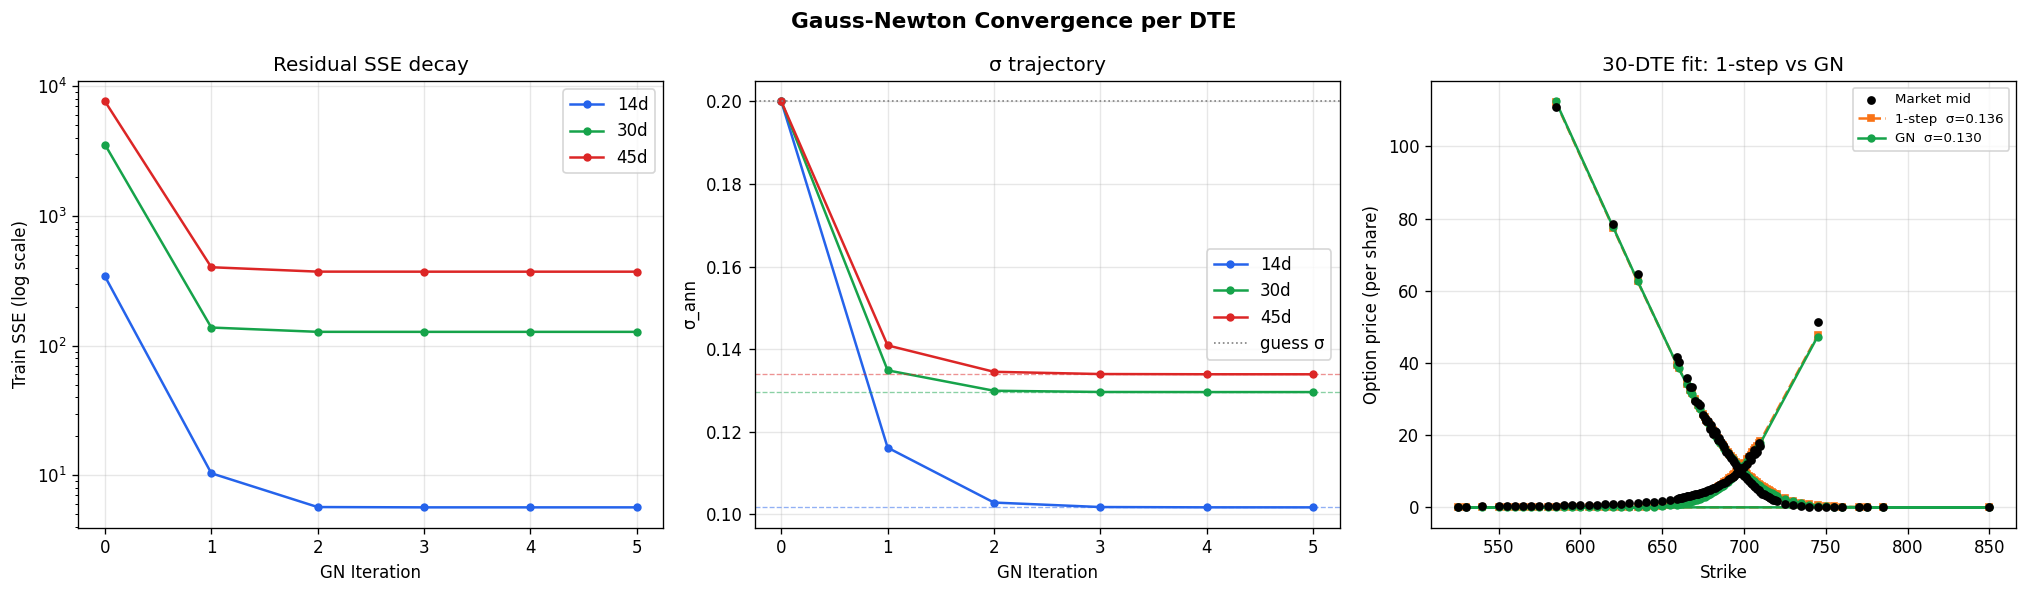


─── Holdout RMSE comparison ───────────────────────────────────────
DTE      1-step RMSE    GN RMSE     Δ RMSE  n_iter
----------------------------------------------------
14d           0.5346     0.3316    +0.2030       6
30d           1.2748     1.2740    +0.0008       6
45d           1.5649     1.4892    +0.0757       6


In [105]:
if not fits_gn:
    print("No GN fits available — run the cell above first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle("Gauss-Newton Convergence per DTE", fontsize=13, fontweight="bold")

    # ── Left: SSE decay ──────────────────────────────────────────────────────
    ax = axes[0]
    for label, res in fits_gn.items():
        hist = res["gn_history"]
        iters = [h["iter"] for h in hist]
        sses  = [h["sse"]  for h in hist]
        ax.semilogy(iters, sses, marker="o", ms=4, color=COLORS[label], label=label)
    ax.set_xlabel("GN Iteration")
    ax.set_ylabel("Train SSE (log scale)")
    ax.set_title("Residual SSE decay")
    ax.legend()

    # ── Middle: σ trajectory ─────────────────────────────────────────────────
    ax = axes[1]
    for label, res in fits_gn.items():
        hist = res["gn_history"]
        iters  = [h["iter"]  for h in hist]
        sigmas = [h["sigma"] for h in hist]
        ax.plot(iters, sigmas, marker="o", ms=4, color=COLORS[label], label=label)
        ax.axhline(res["sigma_fit"], ls="--", lw=0.8, color=COLORS[label], alpha=0.5)
    ax.axhline(sigma_guess_ann, ls=":", lw=1, color="gray", label="guess σ")
    ax.set_xlabel("GN Iteration")
    ax.set_ylabel("σ_ann")
    ax.set_title("σ trajectory")
    ax.legend()

    # ── Right: 1-step vs GN final fit, market mid scatter for TEST_DTE ───────
    ax = axes[2]
    key = f"{TEST_DTE}d"
    if key in fits_gn and key in fits:
        res_gn = fits_gn[key]
        res_1s = fits[key]
        df_gn  = res_gn["option_df"]
        strikes = df_gn["strike"].values
        mids    = df_gn["market_mid"].values

        ax.scatter(strikes, mids, s=18, color="black", zorder=3, label="Market mid")
        ax.plot(strikes, lognormal_price_vec(df_gn, res_1s["mu_fit"],  res_1s["sigma_fit"],  spot, res_gn["T"]),
                "s--", ms=4, color="#f97316", label=f"1-step  σ={res_1s['sigma_fit']:.3f}")
        ax.plot(strikes, lognormal_price_vec(df_gn, res_gn["mu_fit"],  res_gn["sigma_fit"],  spot, res_gn["T"]),
                "o-",  ms=4, color=COLORS.get(key, "#6366f1"), label=f"GN  σ={res_gn['sigma_fit']:.3f}")
        ax.set_xlabel("Strike")
        ax.set_ylabel("Option price (per share)")
        ax.set_title(f"{TEST_DTE}-DTE fit: 1-step vs GN")
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, f"No {TEST_DTE}d fit", ha="center", va="center",
                transform=ax.transAxes)

    plt.tight_layout()
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────────
    print("\n─── Holdout RMSE comparison ───────────────────────────────────────")
    print(f"{'DTE':<6} {'1-step RMSE':>13} {'GN RMSE':>10} {'Δ RMSE':>10} {'n_iter':>7}")
    print("-" * 52)
    for label in ["14d", "30d", "45d"]:
        if label not in fits_gn or label not in fits:
            continue
        r1  = fits[label]["holdout_rmse_fit"]
        rgn = fits_gn[label]["holdout_rmse_fit"]
        ni  = len(fits_gn[label]["gn_history"])
        print(f"{label:<6} {r1:>13.4f} {rgn:>10.4f} {r1-rgn:>+10.4f} {ni:>7d}")

### 3.5 GN-fit vs ATM-IV baseline: residuals and distribution gap

Three-panel per DTE:
- **Left** — per-option pricing residuals: GN-fit (filled bars) vs ATM-IV model (outline bars).  Smaller residuals = better calibration to the full smile.
- **Center** — PDF overlay for the chosen DTE: GN-fit (solid) vs ATM-IV (dashed) vs single-step (dotted).
- **Right** — cumulative probability mass shifted: difference between the two CDFs, highlighting where the fitted drift moves weight relative to the risk-neutral IV measure.

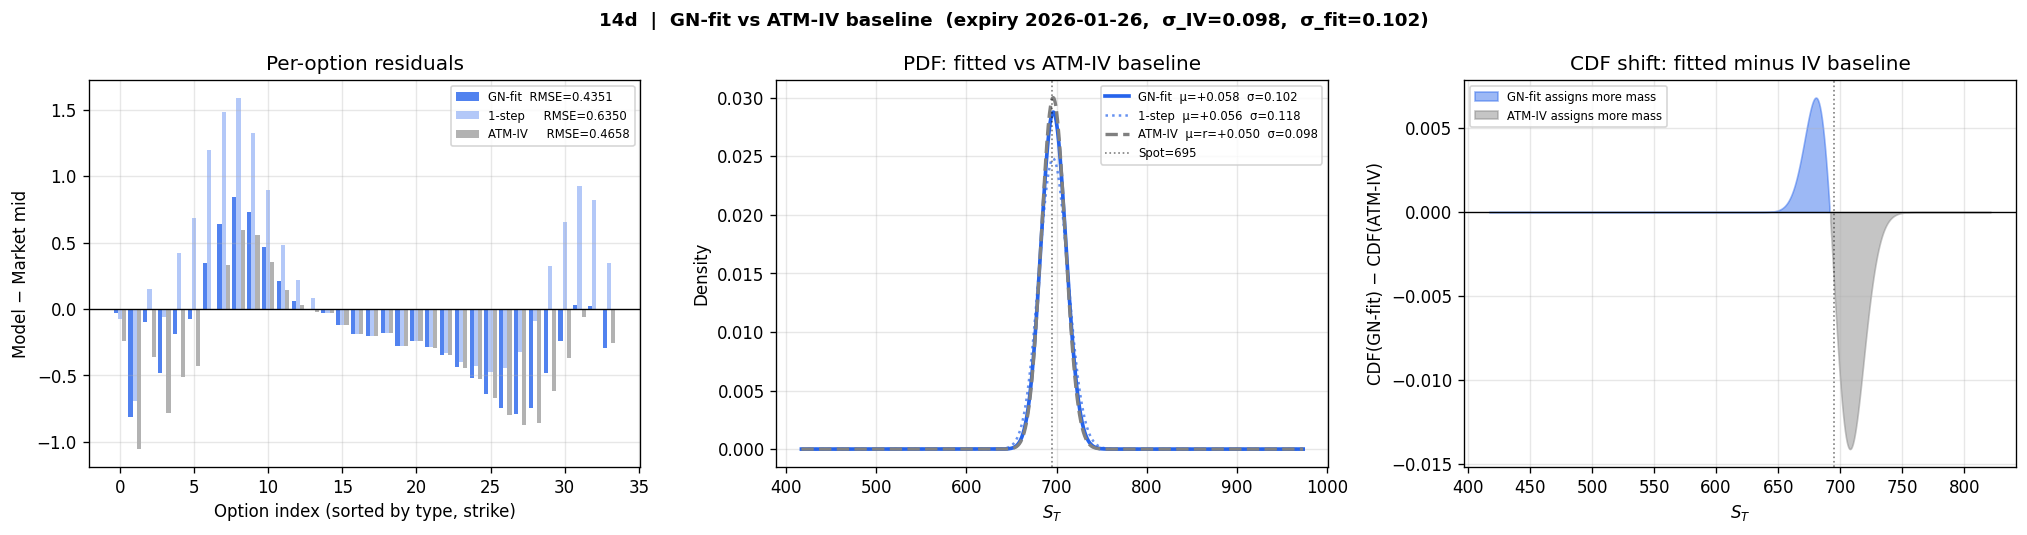

  [14d]  RMSE — GN-fit: 0.4351  |  1-step: 0.6350  |  ATM-IV: 0.4658  |  GN vs IV: +0.0307


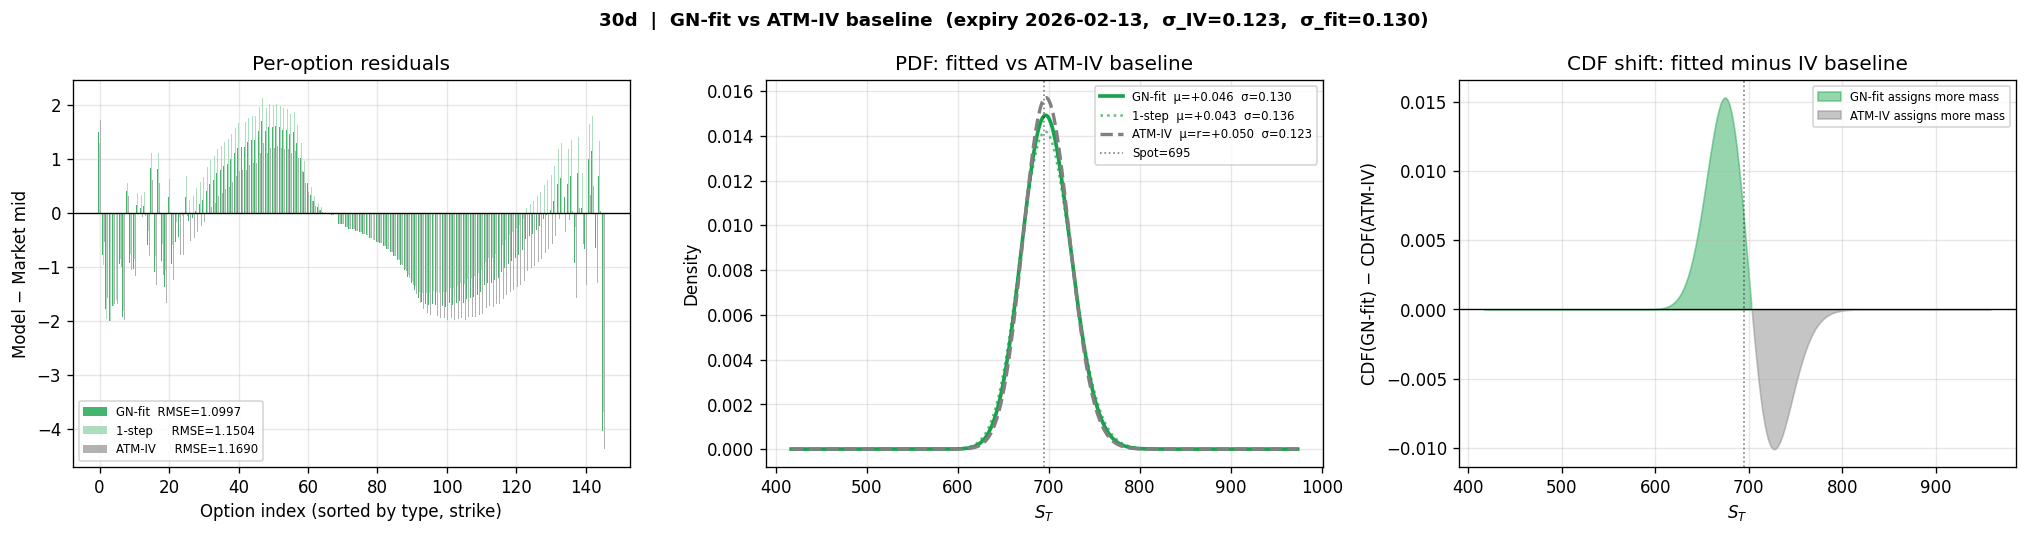

  [30d]  RMSE — GN-fit: 1.0997  |  1-step: 1.1504  |  ATM-IV: 1.1690  |  GN vs IV: +0.0693


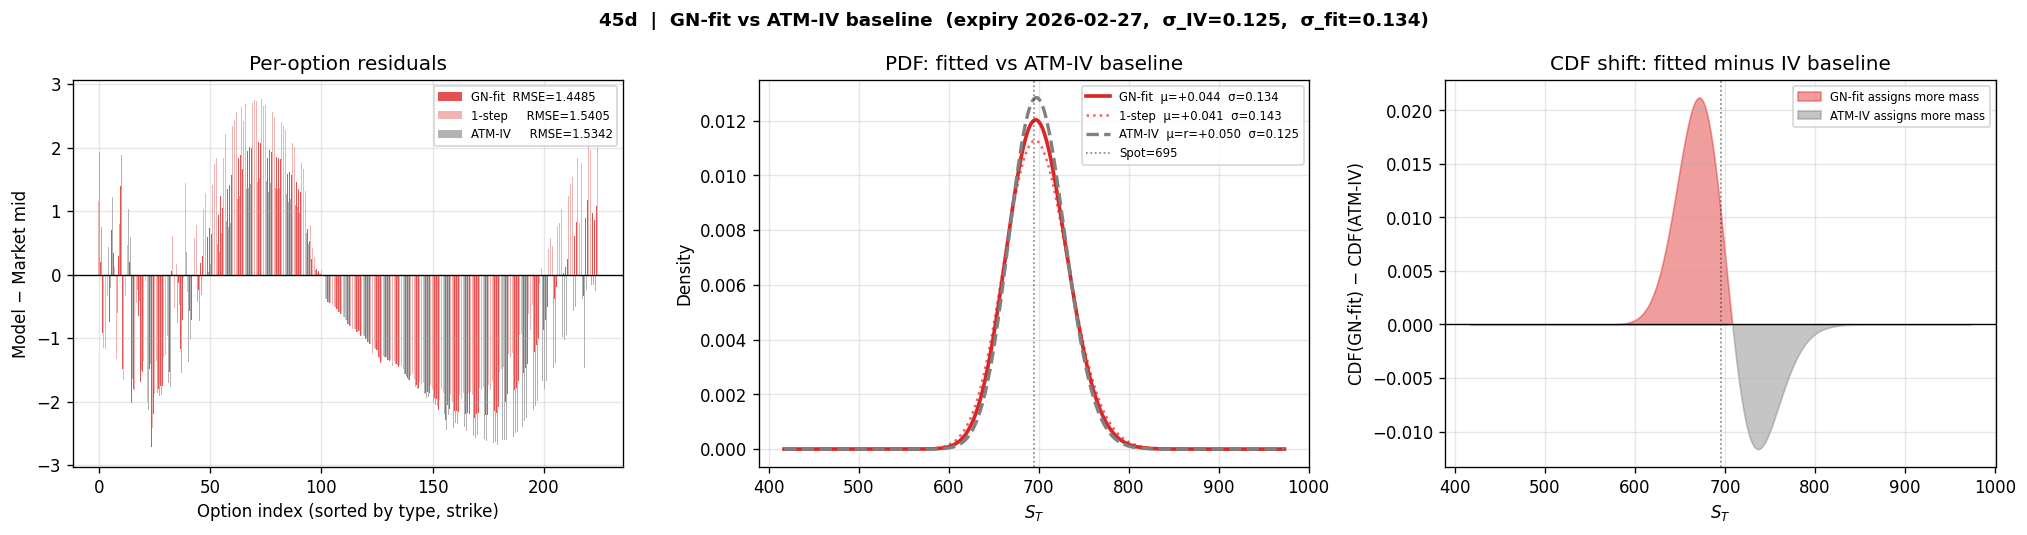

  [45d]  RMSE — GN-fit: 1.4485  |  1-step: 1.5405  |  ATM-IV: 1.5342  |  GN vs IV: +0.0857


In [106]:
_iv   = globals().get('iv_cache',  {})
_gn22 = globals().get('fits_gn',   {})

if not _iv:
    print("iv_cache is empty — re-run §3.2 overlay cell first.")
else:
    from scipy.stats import lognorm as lognorm_sp

    for label in ["14d", "30d", "45d"]:
        if label not in fits or label not in _iv:
            continue

        res_1s  = fits[label]
        iv_info = _iv[label]
        # Use GN option_df if available (has fit_price_gn); fall back to 1-step df
        gn_ran  = label in _gn22
        res_gn  = _gn22[label] if gn_ran else res_1s
        T_      = res_gn["T"]
        s0      = res_gn["spot"]
        color   = COLORS[label]

        # ── Build a clean working DataFrame ──────────────────────────────────
        # Always start from the single-step option_df so columns are consistent
        df_opts = res_1s["option_df"].copy()

        # GN model prices (recompute from GN params if GN ran, else 1-step)
        mu_gn    = res_gn["mu_fit"]
        sig_gn   = res_gn["sigma_fit"]
        df_opts["gn_price"] = lognormal_price_vec(df_opts, mu_gn, sig_gn, s0, T_)

        # 1-step model prices (already in option_df as "fit_price")
        df_opts["1s_price"] = lognormal_price_vec(
            df_opts, res_1s["mu_fit"], res_1s["sigma_fit"], s0, T_
        )

        # ATM-IV baseline prices
        df_opts["iv_price"] = np.array([
            lognormal_price(row["strike"], row["type"] == "call",
                            R_ANN, iv_info["sigma_iv"], s0, T_)
            for _, row in df_opts.iterrows()
        ])

        df_opts["gn_resid"] = df_opts["gn_price"] - df_opts["market_mid"]
        df_opts["1s_resid"] = df_opts["1s_price"] - df_opts["market_mid"]
        df_opts["iv_resid"] = df_opts["iv_price"]  - df_opts["market_mid"]

        rmse_gn = np.sqrt((df_opts["gn_resid"]**2).mean())
        rmse_1s = np.sqrt((df_opts["1s_resid"]**2).mean())
        rmse_iv = np.sqrt((df_opts["iv_resid"]**2).mean())

        gn_label = "GN-fit" if gn_ran else "1-step (GN not run)"

        fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
        fig.suptitle(
            f"{label}  |  {gn_label} vs ATM-IV baseline  "
            f"(expiry {iv_info['expiry']},  σ_IV={iv_info['sigma_iv']:.3f},  "
            f"σ_fit={sig_gn:.3f})",
            fontsize=11, fontweight="bold"
        )

        # ── Panel 1: per-option residuals ─────────────────────────────────────
        ax = axes[0]
        x = np.arange(len(df_opts))
        w = 0.28
        ax.bar(x - w,     df_opts["gn_resid"], w, color=color,    alpha=0.80,
               label=f"{gn_label}  RMSE={rmse_gn:.4f}")
        ax.bar(x,         df_opts["1s_resid"], w, color=color,    alpha=0.35,
               label=f"1-step     RMSE={rmse_1s:.4f}")
        ax.bar(x + w,     df_opts["iv_resid"], w, color="gray",   alpha=0.60,
               label=f"ATM-IV     RMSE={rmse_iv:.4f}")
        ax.axhline(0, color="black", lw=0.8)
        ax.set_xlabel("Option index (sorted by type, strike)")
        ax.set_ylabel("Model − Market mid")
        ax.set_title("Per-option residuals")
        ax.legend(fontsize=7)

        # ── Panel 2: PDF comparison ───────────────────────────────────────────
        ax = axes[1]
        S_grid = np.linspace(s0 * 0.60, s0 * 1.40, 800)

        sig_t_gn = max(sig_gn * np.sqrt(T_), 1e-6)
        m_gn     = np.log(s0) + (mu_gn - 0.5 * sig_gn**2) * T_
        pdf_gn   = lognorm.pdf(S_grid, s=sig_t_gn, scale=np.exp(m_gn))

        sig_t_1s = max(res_1s["sigma_fit"] * np.sqrt(T_), 1e-6)
        m_1s     = np.log(s0) + (res_1s["mu_fit"] - 0.5 * res_1s["sigma_fit"]**2) * T_
        pdf_1s   = lognorm.pdf(S_grid, s=sig_t_1s, scale=np.exp(m_1s))

        pdf_iv = iv_lognormal_pdf(S_grid, s0, iv_info["sigma_iv"], T_)

        ax.plot(S_grid, pdf_gn, lw=2.2, color=color,
                label=f"{gn_label}  μ={mu_gn:+.3f}  σ={sig_gn:.3f}")
        ax.plot(S_grid, pdf_1s, lw=1.5, color=color, ls=":", alpha=0.7,
                label=f"1-step  μ={res_1s['mu_fit']:+.3f}  σ={res_1s['sigma_fit']:.3f}")
        ax.plot(S_grid, pdf_iv, lw=2.0, color="gray", ls="--",
                label=f"ATM-IV  μ=r={R_ANN:+.3f}  σ={iv_info['sigma_iv']:.3f}")
        ax.axvline(s0, color="black", ls=":", lw=1.0, alpha=0.5, label=f"Spot={s0:.0f}")
        ax.set_xlabel("$S_T$")
        ax.set_ylabel("Density")
        ax.set_title("PDF: fitted vs ATM-IV baseline")
        ax.legend(fontsize=7)

        # ── Panel 3: CDF difference (GN-fit − IV baseline) ───────────────────
        ax = axes[2]
        cdf_gn = lognorm_sp.cdf(S_grid, s=sig_t_gn, scale=np.exp(m_gn))
        sig_iv_t = max(iv_info["sigma_iv"] * np.sqrt(T_), 1e-6)
        m_iv     = np.log(s0) + (R_ANN - 0.5 * iv_info["sigma_iv"]**2) * T_
        cdf_iv   = lognorm_sp.cdf(S_grid, s=sig_iv_t, scale=np.exp(m_iv))
        diff = cdf_gn - cdf_iv
        ax.fill_between(S_grid, diff, 0, where=(diff > 0), color=color, alpha=0.45,
                        label=f"{gn_label} assigns more mass")
        ax.fill_between(S_grid, diff, 0, where=(diff < 0), color="gray", alpha=0.45,
                        label="ATM-IV assigns more mass")
        ax.axhline(0, color="black", lw=0.8)
        ax.axvline(s0, color="black", ls=":", lw=1.0, alpha=0.5)
        ax.set_xlabel("$S_T$")
        ax.set_ylabel(f"CDF({gn_label}) − CDF(ATM-IV)")
        ax.set_title("CDF shift: fitted minus IV baseline")
        ax.legend(fontsize=7)

        plt.tight_layout()
        plt.show()

        print(f"  [{label}]  RMSE — {gn_label}: {rmse_gn:.4f}  |  "
              f"1-step: {rmse_1s:.4f}  |  ATM-IV: {rmse_iv:.4f}  "
              f"|  GN vs IV: {rmse_iv - rmse_gn:+.4f}")

---
## 4. Repeated-sample test: predicted μ and Σ vs realized

We test the chosen log-normal distribution (`TEST_DTE`) over many historical windows:

1. Draw `N_SAMPLES` chain dates from history (at least `MIN_DAYS_BACK` before the last close).  
2. On each date, fit the log-normal to calls + puts at `TEST_DTE`.  
3. Sample parameter uncertainty → sample $S_T$ → compute predicted μ and Σ for  
   **(underlying, ATM call, ATM put)**.  
4. Look up the **realized** outcome at expiry (or at the expiry date using SPY daily data).  
5. Aggregate: distribution of (predicted μ − realized return), predicted Σ vs realized Σ.

In [107]:
# ── Build pool of eligible test dates ──────────────────────────────────────
test_eligible = [
    d for d in chain_dates_all
    if (last_close_date - pd.Timestamp(d)).days >= MIN_DAYS_BACK
]

rng_test = np.random.default_rng(42)
if len(test_eligible) <= N_SAMPLES:
    sampled_dates = test_eligible
else:
    idx_sample = rng_test.choice(len(test_eligible), size=N_SAMPLES, replace=False)
    sampled_dates = [test_eligible[i] for i in sorted(idx_sample)]

print(f"TEST_DTE={TEST_DTE}  eligible={len(test_eligible)}  "
      f"sampling={len(sampled_dates)} dates")

TEST_DTE=30  eligible=485  sampling=60 dates


In [108]:
# ── Run test across sampled dates ──────────────────────────────────────────
ASSET_NAMES = ["underlying", "call", "put"]
test_rows = []   # one row per sampled date: predicted and realized mu
cov_pred_list = []  # predicted 3x3 Σ per date
cov_real_list = []  # realized 3x3 Σ per date

for chain_date in sampled_dates:
    try:
        ref_ts  = pd.Timestamp(chain_date)
        idx_ref = prices.index.get_indexer([ref_ts], method="ffill")[0]
        if idx_ref < 0:
            continue
        spot_ref = float(prices.iloc[idx_ref]["close"])

        opt_df, expiry_str, T_ref = load_options_for_dte(
            chain_date, TEST_DTE, spot_ref, r=R_ANN
        )
        recent_lr = prices.loc[prices.index <= ref_ts, "log_ret"].iloc[-LOOKBACK_DAYS:].dropna()
        mu_g  = float(recent_lr.mean() * 252) if len(recent_lr) else 0.0
        sig_g = max(float(recent_lr.std() * np.sqrt(252)) if len(recent_lr) >= 2 else 0.15, 1e-4)

        res = fit_lognormal(opt_df, spot_ref, T_ref, r=R_ANN,
                            mu_guess=mu_g, sigma_guess=sig_g)

        # ATM call and put (model price and market mid)
        calls_sub = opt_df[opt_df["type"] == "call"]
        puts_sub  = opt_df[opt_df["type"] == "put"]
        if len(calls_sub) == 0 or len(puts_sub) == 0:
            continue
        K_call = float(calls_sub.loc[(calls_sub["strike"] - spot_ref).abs().idxmin(), "strike"])
        K_put  = float(puts_sub.loc[(puts_sub["strike"]  - spot_ref).abs().idxmin(), "strike"])
        C0_model = lognormal_price(K_call, True,  res["mu_fit"], res["sigma_fit"], spot_ref, T_ref)
        P0_model = lognormal_price(K_put,  False, res["mu_fit"], res["sigma_fit"], spot_ref, T_ref)
        C0_mkt   = float(calls_sub[calls_sub["strike"] == K_call]["market_mid"].iloc[0])
        P0_mkt   = float(puts_sub [puts_sub ["strike"] == K_put ]["market_mid"].iloc[0])
        if C0_model < 1e-4 or P0_model < 1e-4 or C0_mkt < 1e-4 or P0_mkt < 1e-4:
            continue

        # ── Predicted distribution via parameter sampling ──
        evals, evecs = np.linalg.eigh(res["param_cov"])
        evals = np.clip(evals, 1e-10, None)
        sqrt_cov = evecs @ np.diag(np.sqrt(evals))
        theta_draws = np.array([res["mu_fit"], res["sigma_fit"]]) + \
            rng_test.standard_normal((N_PARAM_DRAWS, 2)) @ sqrt_cov.T
        mu_draws    = np.clip(theta_draws[:, 0], -2.0, 2.0)
        sigma_draws = np.clip(theta_draws[:, 1], 0.02, 1.0)

        pidx = rng_test.integers(0, N_PARAM_DRAWS, size=N_SCENARIOS)
        z    = rng_test.standard_normal(N_SCENARIOS)
        log_st = (np.log(spot_ref)
                  + (mu_draws[pidx] - 0.5 * sigma_draws[pidx]**2) * T_ref
                  + sigma_draws[pidx] * np.sqrt(T_ref) * z)
        S_T_s = np.exp(log_st)

        R_und_p  = (S_T_s - spot_ref) / spot_ref
        R_call_p = (np.maximum(S_T_s - K_call, 0.0) - C0_model) / C0_model
        R_put_p  = (np.maximum(K_put - S_T_s, 0.0) - P0_model) / P0_model
        R_pred   = np.column_stack([R_und_p, R_call_p, R_put_p])
        mu_pred_v  = R_pred.mean(axis=0)
        Sig_pred   = np.cov(R_pred, rowvar=False)

        # ── Realized outcome ──
        exp_ts  = pd.Timestamp(expiry_str)
        # realized end = expiry or last available, whichever is earlier
        real_end_ts = min(last_close_date, exp_ts)
        idx_end = prices.index.get_indexer([real_end_ts], method="ffill")[0]
        if idx_end < 0:
            continue
        spot_end    = float(prices.iloc[idx_end]["close"])
        R_und_real  = (spot_end - spot_ref) / spot_ref
        R_call_real = (max(spot_end - K_call, 0.0) - C0_mkt) / C0_mkt
        R_put_real  = (max(K_put - spot_end, 0.0)  - P0_mkt) / P0_mkt
        mu_real_v   = np.array([R_und_real, R_call_real, R_put_real])

        # ── Realized DAILY covariance (scaled to period) ──
        try:
            iv_obj = lambda sig: _bs_call_price(spot_ref, K_call, R_ANN, T_ref, sig) - C0_mkt
            iv_atm = float(brentq(iv_obj, 0.01, 2.0))
        except Exception:
            iv_atm = res["sigma_fit"]

        spy_slice  = prices.loc[ref_ts:real_end_ts, "close"]
        dates_sl   = spy_slice.index
        spots_sl   = spy_slice.values.astype(float)
        nd         = len(spots_sl)
        if nd < 3:
            continue

        T_rem = np.array([max((exp_ts - d).days / 365.0, 1e-6) for d in dates_sl])
        cv    = np.zeros(nd)
        pv    = np.zeros(nd)
        for i in range(nd):
            if dates_sl[i] < exp_ts and T_rem[i] > 1 / 365.0:
                cv[i] = max(_bs_call_price(spots_sl[i], K_call, R_ANN, T_rem[i], iv_atm), 0.01)
                pv[i] = max(_bs_put_price( spots_sl[i], K_put,  R_ANN, T_rem[i], iv_atm), 0.01)
            else:
                cv[i] = max(spots_sl[i] - K_call, 0.01)
                pv[i] = max(K_put - spots_sl[i],  0.01)

        r_und_d  = (spots_sl[1:] - spots_sl[:-1]) / spots_sl[:-1]
        r_call_d = (cv[1:] - cv[:-1]) / cv[:-1]
        r_put_d  = (pv[1:] - pv[:-1]) / pv[:-1]
        R_daily  = np.column_stack([r_und_d, r_call_d, r_put_d])
        n_days   = R_daily.shape[0]
        Sig_real = n_days * np.cov(R_daily, rowvar=False)

        test_rows.append(dict(
            chain_date=chain_date,
            expiry=expiry_str,
            actual_dte=round(T_ref * 365),
            spot_entry=spot_ref,
            spot_end=spot_end,
            mu_pred_und=mu_pred_v[0],  mu_real_und=mu_real_v[0],
            mu_pred_call=mu_pred_v[1], mu_real_call=mu_real_v[1],
            mu_pred_put=mu_pred_v[2],  mu_real_put=mu_real_v[2],
            vol_pred_und=float(np.sqrt(max(Sig_pred[0, 0], 0))),
            vol_pred_call=float(np.sqrt(max(Sig_pred[1, 1], 0))),
            vol_pred_put=float(np.sqrt(max(Sig_pred[2, 2], 0))),
            vol_real_und=float(np.sqrt(max(Sig_real[0, 0], 0))),
            vol_real_call=float(np.sqrt(max(Sig_real[1, 1], 0))),
            vol_real_put=float(np.sqrt(max(Sig_real[2, 2], 0))),
        ))
        cov_pred_list.append(Sig_pred)
        cov_real_list.append(Sig_real)

    except Exception:
        continue

test_df = pd.DataFrame(test_rows)
print(f"Test complete: {len(test_df)} windows with valid predictions and realized data.")
if len(test_df) > 0:
    print(test_df[["chain_date", "expiry", "actual_dte",
                   "mu_pred_und", "mu_real_und",
                   "mu_pred_call", "mu_real_call"]].head(10).to_string(index=False))

Test complete: 60 windows with valid predictions and realized data.
chain_date     expiry  actual_dte  mu_pred_und  mu_real_und  mu_pred_call  mu_real_call
2024-03-04 2024-04-05          32     0.004747     0.011966     -0.003844     -0.133423
2024-03-14 2024-04-12          29     0.001932    -0.007962      0.007899     -1.000000
2024-03-18 2024-04-19          32     0.007815    -0.034512      0.001039     -1.000000
2024-03-26 2024-04-26          31     0.008158    -0.020335      0.003469     -1.000000
2024-03-27 2024-04-26          30     0.003363    -0.028499      0.000488     -1.000000
2024-04-01 2024-05-03          32     0.006644    -0.020817      0.003772     -1.000000
2024-04-03 2024-05-03          30     0.006589    -0.015633      0.004680     -1.000000
2024-04-23 2024-05-24          31     0.003019     0.047048      0.006570      1.441667
2024-05-17 2024-06-14          28     0.006182     0.025177      0.006014      0.859649
2024-05-21 2024-06-21          31     0.007857     0

### 4.1 Predicted μ vs realized return — scatter and bias

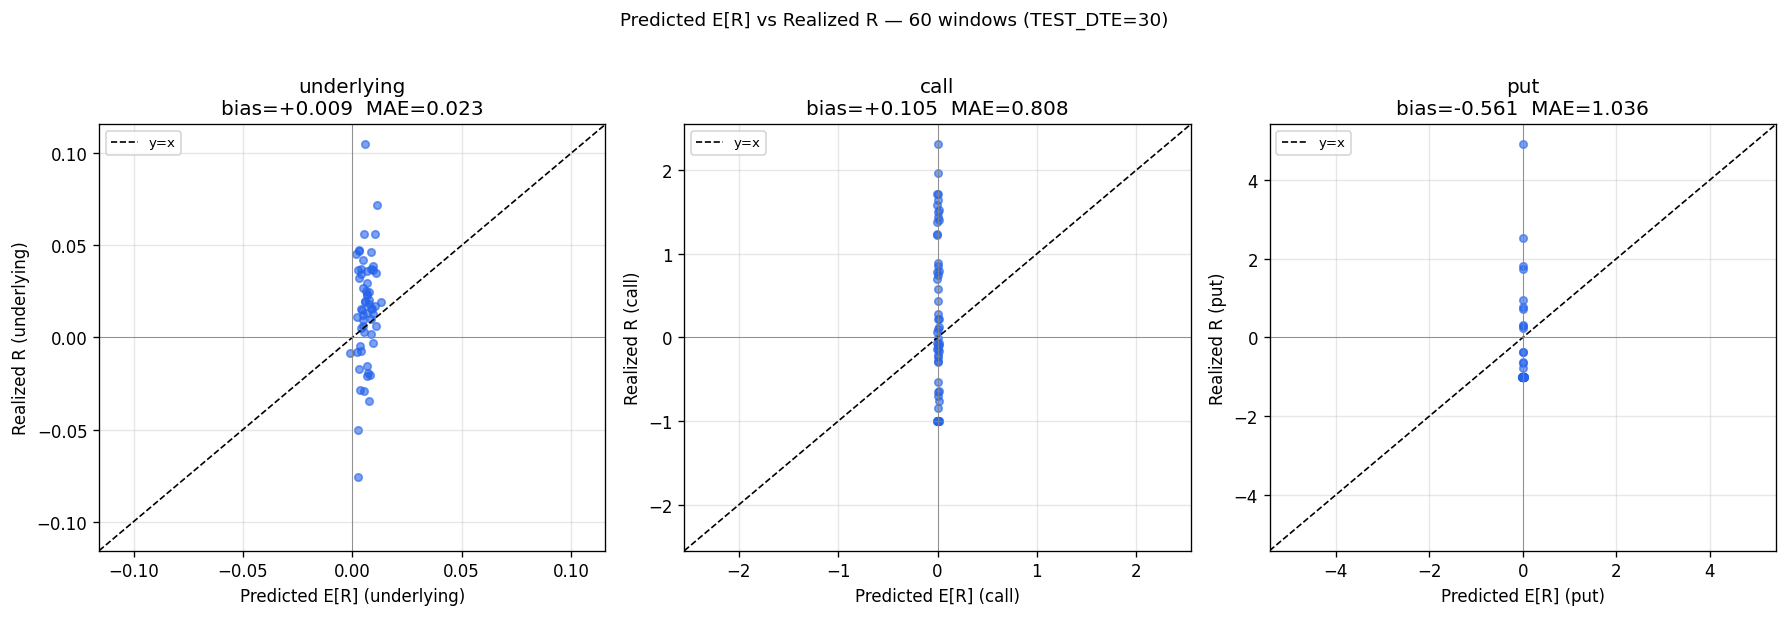

In [109]:
if len(test_df) == 0:
    print("No test results — skipping plots.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, asset, pred_col, real_col in zip(
        axes,
        ASSET_NAMES,
        ["mu_pred_und",  "mu_pred_call",  "mu_pred_put"],
        ["mu_real_und",  "mu_real_call",  "mu_real_put"],
    ):
        x = test_df[pred_col].values
        y = test_df[real_col].values
        ax.scatter(x, y, s=20, alpha=0.6, color="#2563eb")
        lim = max(abs(x).max(), abs(y).max()) * 1.1
        ax.plot([-lim, lim], [-lim, lim], "k--", lw=1, label="y=x")
        ax.axhline(0, color="gray", lw=0.5)
        ax.axvline(0, color="gray", lw=0.5)
        bias = float((y - x).mean())
        mae  = float(np.abs(y - x).mean())
        ax.set_xlabel(f"Predicted E[R] ({asset})")
        ax.set_ylabel(f"Realized R ({asset})")
        ax.set_title(f"{asset}\nbias={bias:+.3f}  MAE={mae:.3f}")
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
        ax.legend(fontsize=8)

    plt.suptitle(
        f"Predicted E[R] vs Realized R — {len(test_df)} windows "
        f"(TEST_DTE={TEST_DTE})",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()

### 4.2 Predicted vol vs realized vol per asset

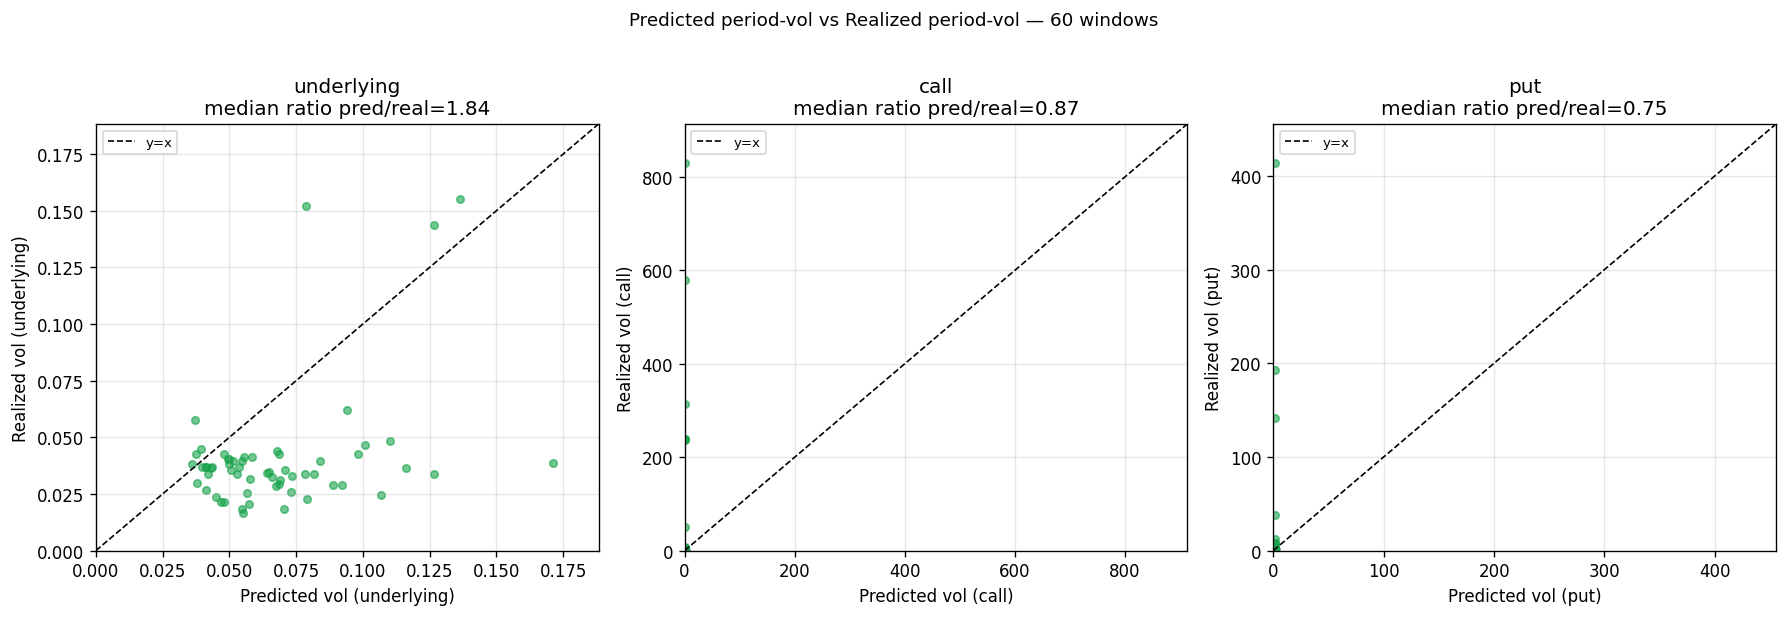

In [110]:
if len(test_df) == 0:
    print("No test results — skipping.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, asset, pred_col, real_col in zip(
        axes,
        ASSET_NAMES,
        ["vol_pred_und",  "vol_pred_call",  "vol_pred_put"],
        ["vol_real_und",  "vol_real_call",  "vol_real_put"],
    ):
        x = test_df[pred_col].values
        y = test_df[real_col].values
        ax.scatter(x, y, s=20, alpha=0.6, color="#16a34a")
        lim = max(x.max(), y.max()) * 1.1
        ax.plot([0, lim], [0, lim], "k--", lw=1, label="y=x")
        ratio = float(np.nanmean(x / np.where(y > 1e-9, y, np.nan)))
        ax.set_xlabel(f"Predicted vol ({asset})")
        ax.set_ylabel(f"Realized vol ({asset})")
        ax.set_title(f"{asset}\nmedian ratio pred/real={np.nanmedian(x/np.where(y>1e-9,y,np.nan)):.2f}")
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.legend(fontsize=8)

    plt.suptitle(
        f"Predicted period-vol vs Realized period-vol — {len(test_df)} windows",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()

### 4.3 Average predicted and realized covariance matrices

Average PREDICTED covariance matrix (60 windows, TEST_DTE=30):
            underlying      call       put
underlying    0.005375  0.087194 -0.083475
call          0.087194  2.068435 -1.007919
put          -0.083475 -1.007919  2.288118

Average REALIZED covariance matrix:
            underlying          call          put
underlying    0.002350      1.404954    -0.372150
call          1.404954  21608.937282   -99.932291
put          -0.372150    -99.932291  3845.495926

Average PREDICTED correlation:
            underlying    call     put
underlying      1.0000  0.8269 -0.7527
call            0.8269  1.0000 -0.4633
put            -0.7527 -0.4633  1.0000

Average REALIZED correlation:
            underlying    call     put
underlying      1.0000  0.1972 -0.1238
call            0.1972  1.0000 -0.0110
put            -0.1238 -0.0110  1.0000


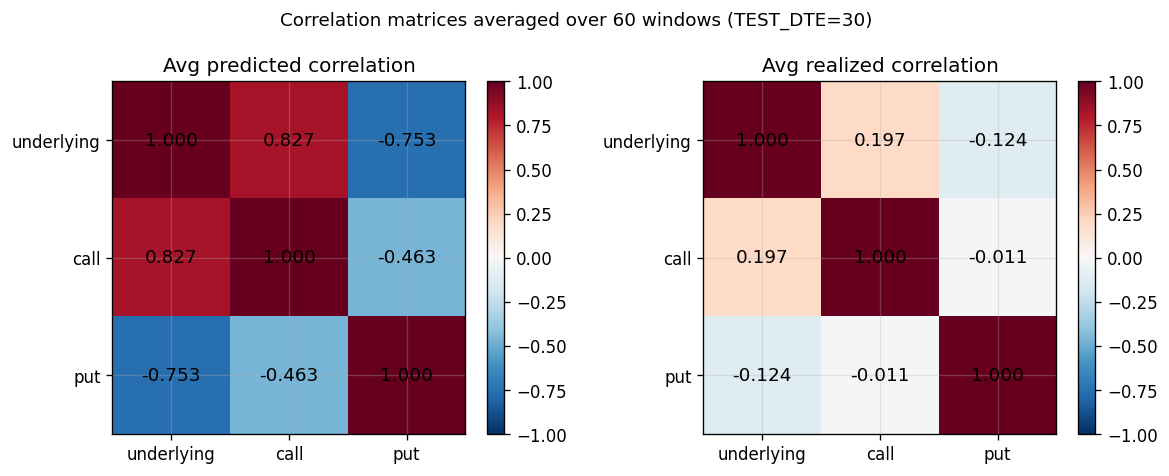

In [111]:
if len(cov_pred_list) == 0:
    print("No covariance data.")
else:
    Sig_pred_avg = np.mean(np.stack(cov_pred_list, axis=0), axis=0)
    Sig_real_avg = np.mean(np.stack(cov_real_list, axis=0), axis=0)

    def _to_corr(S):
        d = np.sqrt(np.maximum(np.diag(S), 1e-20))
        return S / np.outer(d, d)

    print(f"Average PREDICTED covariance matrix ({len(cov_pred_list)} windows, TEST_DTE={TEST_DTE}):")
    print(pd.DataFrame(Sig_pred_avg, index=ASSET_NAMES, columns=ASSET_NAMES).round(6).to_string())

    print(f"\nAverage REALIZED covariance matrix:")
    print(pd.DataFrame(Sig_real_avg, index=ASSET_NAMES, columns=ASSET_NAMES).round(6).to_string())

    print("\nAverage PREDICTED correlation:")
    print(pd.DataFrame(_to_corr(Sig_pred_avg), index=ASSET_NAMES, columns=ASSET_NAMES).round(4).to_string())

    print("\nAverage REALIZED correlation:")
    print(pd.DataFrame(_to_corr(Sig_real_avg), index=ASSET_NAMES, columns=ASSET_NAMES).round(4).to_string())

    # Heatmap comparison
    import matplotlib.colors as mcolors
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, mat, title in [
        (axes[0], _to_corr(Sig_pred_avg), "Avg predicted correlation"),
        (axes[1], _to_corr(Sig_real_avg), "Avg realized correlation"),
    ]:
        im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r")
        ax.set_xticks(range(3)); ax.set_yticks(range(3))
        ax.set_xticklabels(ASSET_NAMES); ax.set_yticklabels(ASSET_NAMES)
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center",
                        fontsize=11, color="black")
        ax.set_title(title)
        plt.colorbar(im, ax=ax, fraction=0.046)

    plt.suptitle(
        f"Correlation matrices averaged over {len(cov_pred_list)} windows "
        f"(TEST_DTE={TEST_DTE})",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

### 4.4 Realized-return percentile in predicted distribution

For each window and each asset, we record where the realized return falls in the predicted distribution. Under a well-calibrated model this should be roughly uniform on [0, 100].


── μ prediction summary (mean ± std of error = realized − predicted) ──
  underlying    bias=+0.0091  std=0.0291  MAE=0.0234  corr(pred,real)=0.227
  call          bias=+0.1046  std=0.9753  MAE=0.8080  corr(pred,real)=-0.143
  put           bias=-0.5608  std=1.0664  MAE=1.0356  corr(pred,real)=-0.011

── Volatility ratio (predicted / realized) ──
  underlying    median ratio=1.840  mean ratio=1.947  std=0.918
  call          median ratio=0.874  mean ratio=0.930  std=0.651
  put           median ratio=0.754  mean ratio=0.733  std=0.324


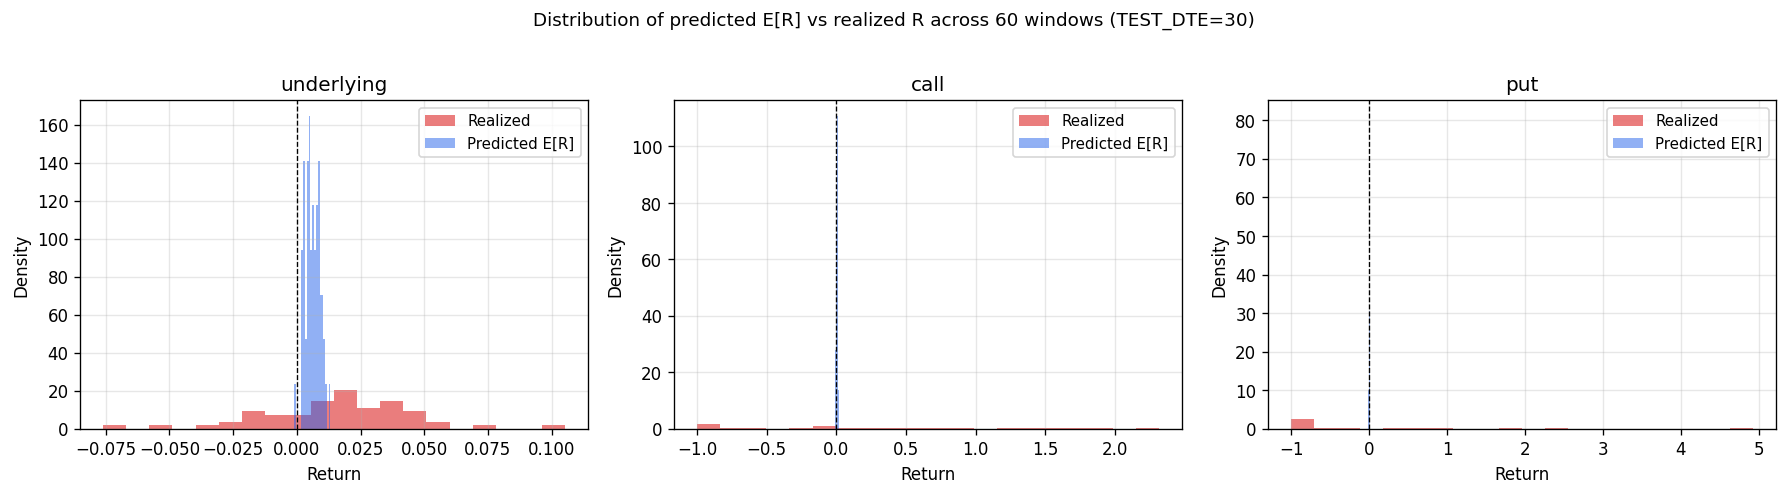

In [112]:
if len(test_df) == 0:
    print("No test results.")
else:
    # Summary statistics
    print("\n── μ prediction summary (mean ± std of error = realized − predicted) ──")
    for asset, pred_col, real_col in zip(
        ASSET_NAMES,
        ["mu_pred_und",  "mu_pred_call",  "mu_pred_put"],
        ["mu_real_und",  "mu_real_call",  "mu_real_put"],
    ):
        err = test_df[real_col] - test_df[pred_col]
        print(f"  {asset:12s}  bias={err.mean():+.4f}  std={err.std():.4f}  "
              f"MAE={err.abs().mean():.4f}  "
              f"corr(pred,real)={test_df[pred_col].corr(test_df[real_col]):.3f}")

    print("\n── Volatility ratio (predicted / realized) ──")
    for asset, pred_col, real_col in zip(
        ASSET_NAMES,
        ["vol_pred_und",  "vol_pred_call",  "vol_pred_put"],
        ["vol_real_und",  "vol_real_call",  "vol_real_put"],
    ):
        ratio = test_df[pred_col] / test_df[real_col].replace(0, np.nan)
        print(f"  {asset:12s}  median ratio={ratio.median():.3f}  "
              f"mean ratio={ratio.mean():.3f}  std={ratio.std():.3f}")

    # Distribution of predicted vs realized returns
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, asset, pred_col, real_col in zip(
        axes, ASSET_NAMES,
        ["mu_pred_und",  "mu_pred_call",  "mu_pred_put"],
        ["mu_real_und",  "mu_real_call",  "mu_real_put"],
    ):
        ax.hist(test_df[real_col], bins=20, alpha=0.6,
                color="#dc2626", label="Realized", density=True)
        ax.hist(test_df[pred_col], bins=20, alpha=0.5,
                color="#2563eb", label="Predicted E[R]", density=True)
        ax.axvline(0, color="black", lw=0.8, ls="--")
        ax.set_title(f"{asset}")
        ax.set_xlabel("Return")
        ax.set_ylabel("Density")
        ax.legend(fontsize=9)

    plt.suptitle(
        f"Distribution of predicted E[R] vs realized R across "
        f"{len(test_df)} windows (TEST_DTE={TEST_DTE})",
        fontsize=11, y=1.02
    )
    plt.tight_layout()
    plt.show()

---
## 5. Walk-Forward Min-Variance Backtest — 2023 Full Year

**Data**: `optionsdx_csv` free-history research panel — SPY, AAPL, NVDA, TSLA  
**4 symbols × 250 daily dates × 5 assets each** (underlying + 2 calls + 2 puts, pre-cleaned, zero NaN).

**Three experiments — all pure minimum-variance (no μ used):**

| Experiment | Universe |
|---|---|
| **0 · Stocks only** | SPY, AAPL, NVDA, TSLA |
| **A · SPY options + stocks** | SPY_und, SPY_call1, SPY_put1, AAPL, NVDA, TSLA |
| **B · All options** | each symbol gets its own ATM call + ATM put |

**Covariance**: rolling 21-day empirical covariance of *realized* daily returns — the most direct use of the research panel data.  
**Rebalance**: every 5 trading days (weekly). Long-only, fully invested, weight cap 50%.  
**Benchmark**: equal-weight stocks (SPY + AAPL + NVDA + TSLA, 25% each, held static).

$$\Sigma_{\text{structural}} = \underbrace{V \,\sigma_{\text{und}}^2 T\, V^\top}_{\text{systematic, from GN }\sigma} + \underbrace{D}_{\text{empirical option noise floor}}$$

where $V = [1,\; \delta^{\%}_{\text{call}},\; \delta^{\%}_{\text{put}}]^\top$ and $\delta^{\%}_i = (\partial C_i/\partial S) \cdot S_0 / C_{i,0}$ converts price-delta to return-space sensitivity.  Robustness is added via $A_{\text{eff}} = \Sigma_{\text{structural}} + \varepsilon_{\text{wc}} \, V V^\top$.

**Two portfolios compared — both pure minimum-variance (no $\mu$ used):**
1. **Stocks only** — SPY underlying alone; baseline portfolio vol = $\sigma_{\text{GN}} \sqrt{T}$
2. **Stocks + Options** — $\{$SPY, ATM call, ATM put$\}$; three covariance variants:
   - Structural $\Sigma$ from GN fit + BS deltas
   - Robust $A_{\text{eff}}$ (adds $\varepsilon_{\text{wc}}$ penalty)
   - §4 average predicted $\Sigma$ (Monte-Carlo covariance from section 4, if available)

In [113]:
# ── Config ───────────────────────────────────────────────────────────────────
from pathlib import Path as _Path

_PANEL_PATH  = _Path("data/processed/free_history/research_panel_optionsdx_csv.parquet")
_LOOKBACK    = 21     # rolling-window trading days for empirical covariance
_REBAL_FREQ  = 5      # rebalance every N trading days
_MAX_WT      = 0.50   # maximum weight per single asset
_SYMS        = ["SPY", "AAPL", "NVDA", "TSLA"]

# ── Load research panel ───────────────────────────────────────────────────────
_rp = pd.read_parquet(_PANEL_PATH)
_rp["date_t"] = pd.to_datetime(_rp["date_t"])
_rp = _rp.sort_values(["symbol", "date_t"]).reset_index(drop=True)

# ── Build wide returns DataFrame: date × all assets ──────────────────────────
_ret_blocks = []
for _sym in _SYMS:
    _sub = _rp[_rp["symbol"] == _sym].set_index("date_t")
    for _col, _new in [
        ("R_und_real",   f"{_sym}"),
        ("call_1_R_real", f"{_sym}_call1"),
        ("put_1_R_real",  f"{_sym}_put1"),
        ("call_2_R_real", f"{_sym}_call2"),
        ("put_2_R_real",  f"{_sym}_put2"),
    ]:
        if _col in _sub.columns:
            _ret_blocks.append(_sub[[_col]].rename(columns={_col: _new}))

_rets_all = pd.concat(_ret_blocks, axis=1).sort_index()

# ── Common date index (inner join — all 4 symbols present) ───────────────────
_common_dates = _rets_all.dropna(subset=_SYMS).index   # at least all underlyings valid
_rets_all     = _rets_all.loc[_common_dates]

print(f"Returns matrix : {_rets_all.shape[0]} dates × {_rets_all.shape[1]} assets")
print(f"Date range     : {_rets_all.index.min().date()} → {_rets_all.index.max().date()}")
print(f"Assets         : {list(_rets_all.columns)}")
print(f"\nAnnualized stats (full sample):")
_ann = _rets_all.describe().T[["mean","std"]].copy()
_ann["ann_return"] = _ann["mean"]  * 252
_ann["ann_vol"]    = _ann["std"]   * np.sqrt(252)
print(_ann[["ann_return","ann_vol"]].applymap(lambda x: f"{x:.2%}").to_string())

if _test_key not in fits:
    raise RuntimeError(f"Run §3 single-step fits first (missing key '{_test_key}').")

res_best = _gn5.get(_test_key, fits[_test_key])   # prefer GN; fall back to 1-step
fit_src  = "GN-iterative" if _test_key in _gn5 else "1-step"

T_opt   = res_best["T"]
s0_opt  = res_best["spot"]
mu_opt  = res_best["mu_fit"]      # NOTE: not used in min-var objective — only for pricing
sig_opt = res_best["sigma_fit"]

# ── ATM strikes ───────────────────────────────────────────────────────────────
df_opts5  = res_best["option_df"]
calls5    = df_opts5[df_opts5["type"] == "call"]
puts5     = df_opts5[df_opts5["type"] == "put"]
K_call5   = float(calls5.loc[(calls5["strike"] - s0_opt).abs().idxmin(), "strike"])
K_put5    = float(puts5.loc[(puts5["strike"]  - s0_opt).abs().idxmin(), "strike"])

# Model prices under GN (or 1-step) fit
C0 = lognormal_price(K_call5, True,  mu_opt, sig_opt, s0_opt, T_opt, R_ANN)
P0 = lognormal_price(K_put5,  False, mu_opt, sig_opt, s0_opt, T_opt, R_ANN)
C0 = max(C0, 1e-4)
P0 = max(P0, 1e-4)

# ── Black-Scholes delta → return-space sensitivity ────────────────────────────
# d1 computed under GN drift (used for pricing consistency)
sig_t5 = max(sig_opt * np.sqrt(T_opt), 1e-6)
d1_c   = (np.log(s0_opt / K_call5) + (mu_opt + 0.5 * sig_opt**2) * T_opt) / sig_t5
d1_p   = (np.log(s0_opt / K_put5)  + (mu_opt + 0.5 * sig_opt**2) * T_opt) / sig_t5

delta_call_bs  = norm.cdf(d1_c)          # dC/dS  (price delta)
delta_put_bs   = norm.cdf(d1_p) - 1.0   # dP/dS  (price delta, negative for puts)

# Return-space delta: (dC/dS * S) / C0  ≈  d(R_call) / d(R_und)
delta_call_ret = delta_call_bs * s0_opt / C0
delta_put_ret  = delta_put_bs  * s0_opt / P0

ASSET_LABELS5 = [
    "SPY (underlying)",
    f"ATM Call  K={K_call5:.0f}",
    f"ATM Put   K={K_put5:.0f}",
]

print(f"Fit source : {fit_src}  (μ={mu_opt:+.4f}, σ={sig_opt:.4f})")
print(f"Expiry     : {res_best['expiry']}   T={T_opt:.4f} yr  ({round(T_opt*365)}d)")
print(f"Spot       : {s0_opt:.2f}")
print(f"ATM call   : K={K_call5:.1f}   model price={C0:.4f}   δ_ret={delta_call_ret:+.3f}")
print(f"ATM put    : K={K_put5:.1f}   model price={P0:.4f}   δ_ret={delta_put_ret:+.3f}")

# ── Structural covariance  Σ = σ²_und * T * V Vᵀ + D  ───────────────────────
sigma_und_period = sig_opt**2 * T_opt   # underlying period variance
V5 = np.array([1.0, delta_call_ret, delta_put_ret])

Sigma_sys   = sigma_und_period * np.outer(V5, V5)

# Empirical option noise floor: small diagonal bump on option variances
# Calibrated from options_free_history experiment (~5-10% of systematic option variance)
NOISE_FRAC  = 0.08
noise_diag5 = np.diag([0.0,
                        NOISE_FRAC * Sigma_sys[1, 1],
                        NOISE_FRAC * Sigma_sys[2, 2]])
Sigma_struct = Sigma_sys + noise_diag5

# Robust A_eff: add ε_wc * V Vᵀ  (from options_free_history robust formulation)
EPS_WC = 0.05
A_eff5 = Sigma_struct + EPS_WC * np.outer(V5, V5)

print(f"\n── Structural Σ (period T={T_opt:.3f} yr) ──")
_df_s = pd.DataFrame(Sigma_struct, index=ASSET_LABELS5, columns=ASSET_LABELS5)
print(_df_s.to_string(float_format=lambda x: f"{x:.6f}"))

print(f"\n── Robust A_eff (ε_wc={EPS_WC}) ──")
_df_a = pd.DataFrame(A_eff5, index=ASSET_LABELS5, columns=ASSET_LABELS5)
print(_df_a.to_string(float_format=lambda x: f"{x:.6f}"))

# ── §4 average predicted covariance (if section 4 was run) ────────────────────
_cov_pred5 = globals().get('cov_pred_list', [])
Sigma_s4   = None
if len(_cov_pred5) >= 5:
    Sigma_s4 = np.mean(np.stack(_cov_pred5, axis=0), axis=0)
    print(f"\n── §4 avg predicted Σ ({len(_cov_pred5)} windows) ──")
    _df_4 = pd.DataFrame(Sigma_s4, index=ASSET_LABELS5, columns=ASSET_LABELS5)
    print(_df_4.to_string(float_format=lambda x: f"{x:.6f}"))
else:
    print("\n(§4 covariance not available — run section 4 to enable that comparison.)")

Returns matrix : 245 dates × 20 assets
Date range     : 2023-01-05 → 2023-12-28
Assets         : ['SPY', 'SPY_call1', 'SPY_put1', 'SPY_call2', 'SPY_put2', 'AAPL', 'AAPL_call1', 'AAPL_put1', 'AAPL_call2', 'AAPL_put2', 'NVDA', 'NVDA_call1', 'NVDA_put1', 'NVDA_call2', 'NVDA_put2', 'TSLA', 'TSLA_call1', 'TSLA_put1', 'TSLA_call2', 'TSLA_put2']

Annualized stats (full sample):
           ann_return  ann_vol
SPY            23.00%   13.14%
SPY_call1     415.37%  567.79%
SPY_put1    -1479.15%  578.63%
SPY_call2     456.48%  597.90%
SPY_put2    -1555.25%  585.87%
AAPL           45.37%   19.98%
AAPL_call1    580.40%  508.29%
AAPL_put1   -1760.78%  599.73%
AAPL_call2    579.35%  689.37%
AAPL_put2   -2106.30%  630.65%
NVDA          137.23%   48.54%
NVDA_call1   1701.96%  898.85%
NVDA_put1   -2368.44%  629.57%
NVDA_call2   1817.52%  945.68%
NVDA_put2   -2495.00%  651.16%
TSLA          102.18%   52.59%
TSLA_call1    468.40%  582.41%
TSLA_put1   -1545.00%  625.38%
TSLA_call2    574.29%  636.51%
TSLA_p

/var/folders/v7/fy28j8pd6yb_vb5vddcfccd00000gn/T/ipykernel_29210/2888622199.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(_ann[["ann_return","ann_vol"]].applymap(lambda x: f"{x:.2%}").to_string())


In [114]:
import contextlib, io as _io

# ── Silence helper (suppresses fit_lognormal_gn print output in batch) ───────
def _silent(fn, *args, **kwargs):
    with contextlib.redirect_stdout(_io.StringIO()):
        return fn(*args, **kwargs)


# ── Step 1: build mini option DataFrame from one research-panel row ──────────
def _mini_optdf(row):
    rows = []
    for slot, is_call in [("call_1",True),("call_2",True),("put_1",False),("put_2",False)]:
        K   = row.get(f"{slot}_strike")
        mid = row.get(f"{slot}_mid_t")
        if pd.notna(K) and pd.notna(mid) and float(mid) > 0.005:
            rows.append({"strike": float(K),
                         "type": "call" if is_call else "put",
                         "market_mid": float(mid)})
    return pd.DataFrame(rows) if len(rows) >= 2 else None


# ── Step 2: GN fit + MC sampling → period-return covariance for one symbol ───
def _gn_sample_cov(row, r=R_ANN, n_mc=6_000, n_param=300, rng=None):
    """
    Fit GN log-normal to the 4 panel contracts, sample parameter uncertainty,
    and return the 3×3 period-return covariance for {underlying, ATM_call, ATM_put}.
    """
    if rng is None:
        rng = np.random.default_rng(42)

    opt_df = _mini_optdf(row)
    if opt_df is None:
        return None

    spot  = float(row["spot_t"])
    T     = max(float(row.get("chosen_dte_t") or 21) / 365.0, 2/365)
    sig0  = max(float(row.get("call_1_iv_t") or 0.20), 0.05)

    try:
        res = _silent(fit_lognormal_gn, opt_df, spot_0=spot, T=T, r=r,
                      mu_guess=r, sigma_guess=sig0, max_iter=15)
    except Exception:
        try:                            # fall back to 1-step if GN fails
            res = fit_lognormal(opt_df, spot_0=spot, T=T, r=r,
                                mu_guess=r, sigma_guess=sig0)
        except Exception:
            return None

    # ── Sample parameter uncertainty ──────────────────────────────────────────
    evals, evecs = np.linalg.eigh(res["param_cov"])
    evals    = np.clip(evals, 1e-12, None)
    sqrt_cov = evecs @ np.diag(np.sqrt(evals))

    draws = (np.array([res["mu_fit"], res["sigma_fit"]])
             + rng.standard_normal((n_param, 2)) @ sqrt_cov.T)
    mu_d  = np.clip(draws[:, 0], -2.0, 2.0)
    sig_d = np.clip(draws[:, 1], 0.02, 1.5)

    pidx = rng.integers(0, n_param, n_mc)
    z    = rng.standard_normal(n_mc)
    S_T  = spot * np.exp(
        (mu_d[pidx] - 0.5 * sig_d[pidx]**2) * T
        + sig_d[pidx] * np.sqrt(T) * z
    )

    # ATM call/put (closest strike to spot)
    calls = opt_df[opt_df["type"] == "call"]
    puts  = opt_df[opt_df["type"] == "put"]
    K_c   = float(calls.loc[(calls["strike"] - spot).abs().idxmin(), "strike"])
    K_p   = float(puts.loc[(puts["strike"]  - spot).abs().idxmin(), "strike"])
    C0    = max(lognormal_price(K_c, True,  res["mu_fit"], res["sigma_fit"], spot, T), 1e-4)
    P0    = max(lognormal_price(K_p, False, res["mu_fit"], res["sigma_fit"], spot, T), 1e-4)

    R_und  = (S_T - spot) / spot
    R_call = (np.maximum(S_T - K_c, 0) - C0) / C0
    R_put  = (np.maximum(K_p - S_T, 0) - P0) / P0

    Sig_period = np.cov(np.column_stack([R_und, R_call, R_put]).T)
    Sig_daily  = Sig_period / max(T * 252, 1)   # scale period → daily

    return dict(mu_fit=res["mu_fit"], sigma_fit=res["sigma_fit"],
                K_call=K_c, K_put=K_p, C0=C0, P0=P0, T=T, spot=spot,
                Sigma_daily=Sig_daily)


# ── Step 3: assemble full cross-asset covariance ──────────────────────────────
def _build_full_cov(rebal_date, rp_idx, und_rets_df, syms, asset_cols,
                    lookback=_LOOKBACK):
    """
    Diagonal blocks : GN Monte-Carlo covariance per symbol (forward-looking).
    Off-diagonal blocks : structural formula
                          Cov(R_i, R_j) ≈ sens_i · ρ_und · sens_j · σ_und_i · σ_und_j
    where sens_k = Cov(R_opt_k, R_und_k) / Var(R_und_k)  is the return-space loading.
    """
    rng = np.random.default_rng(int(pd.Timestamp(rebal_date).value % (2**31)))

    # Per-symbol GN covariance
    gn = {}
    for sym in syms:
        df_sym = rp_idx.get(sym)
        if df_sym is None:
            continue
        avail = df_sym.loc[:rebal_date]
        if avail.empty:
            continue
        row = avail.iloc[-1].to_dict()
        result = _gn_sample_cov(row, rng=rng)
        if result:
            gn[sym] = result

    if not gn:
        raise ValueError(f"No GN fits succeeded for {rebal_date}")

    # Rolling underlying cross-correlation
    end_loc   = und_rets_df.index.get_indexer([rebal_date], method="ffill")[0]
    start_loc = max(0, end_loc - lookback)
    corr_df   = und_rets_df.iloc[start_loc:end_loc][syms].dropna().corr()
    Corr      = corr_df.reindex(index=syms, columns=syms).fillna(0).values
    np.fill_diagonal(Corr, 1.0)

    # Asset-type mapping within each symbol's 3×3 block
    TYPE_IDX  = {"": 0, "_call1": 1, "_put1": 2}
    sym_order = {s: i for i, s in enumerate(syms)}

    n       = len(asset_cols)
    sym_of  = [c.split("_")[0] for c in asset_cols]
    suf_of  = [c[len(c.split("_")[0]):] for c in asset_cols]

    Sigma = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            si, sj = sym_of[i], sym_of[j]
            ti = TYPE_IDX.get(suf_of[i], -1)
            tj = TYPE_IDX.get(suf_of[j], -1)
            if ti < 0 or tj < 0 or si not in gn or sj not in gn:
                continue

            gi, gj = gn[si], gn[sj]

            if si == sj:
                Sigma[i, j] = gi["Sigma_daily"][ti, tj]
            else:
                var_i = max(gi["Sigma_daily"][0, 0], 1e-12)
                var_j = max(gj["Sigma_daily"][0, 0], 1e-12)
                # Return-space sensitivities (≈ delta_pct for options, 1.0 for underlying)
                sens_i = 1.0 if ti == 0 else gi["Sigma_daily"][ti, 0] / var_i
                sens_j = 1.0 if tj == 0 else gj["Sigma_daily"][tj, 0] / var_j
                rho    = Corr[sym_order[si], sym_order[sj]]
                Sigma[i, j] = sens_i * rho * sens_j * np.sqrt(var_i * var_j)

    Sigma = 0.5 * (Sigma + Sigma.T)
    Sigma += 1e-7 * np.eye(n)
    return Sigma, gn


# ── Step 4: walk-forward engine (GN covariance + optional min-return) ─────────
def _wf_gn(rets_df, asset_cols, syms, rp_idx, label,
            lookback=_LOOKBACK, rebal_freq=_REBAL_FREQ, max_wt=_MAX_WT,
            min_ann_return=None):
    """
    Walk-forward min-var using GN forward-looking covariance.

    min_ann_return: if set, adds  w^T μ_daily ≥ min_ann_return/252  constraint
      where μ_options = 0 (options only used for variance reduction),
      μ_underlying = rolling mean of daily underlying return.
    """
    cols   = [c for c in asset_cols if c in rets_df.columns]
    rets   = rets_df[cols].copy()
    dates  = rets.index
    und_rets_df = rets_df[syms].copy()

    port_val = {}
    wts_hist = {}
    cur_wts  = {c: 1.0 / len(cols) for c in cols}
    port_val[dates[lookback - 1]] = 1.0

    for i in range(lookback, len(dates)):
        date = dates[i]

        if (i - lookback) % rebal_freq == 0:
            try:
                Sigma, gn_res = _build_full_cov(
                    date, rp_idx, und_rets_df, syms, cols, lookback
                )
                n = len(cols)
                w = cp.Variable(n, nonneg=True)
                constraints = [cp.sum(w) == 1, w <= max_wt]

                if min_ann_return is not None:
                    # μ_daily: rolling mean for underlyings only; 0 for all options
                    mu_daily = np.zeros(n)
                    for k, c in enumerate(cols):
                        if c in syms:   # underlying — use rolling mean
                            hist = rets.iloc[i - lookback:i][c].dropna()
                            mu_daily[k] = float(hist.mean()) if len(hist) else 0.0
                    constraints.append(mu_daily @ w >= min_ann_return / 252)

                prob = cp.Problem(cp.Minimize(cp.quad_form(w, Sigma)), constraints)
                prob.solve(solver=cp.CLARABEL, warm_start=True)
                if w.value is None:
                    prob.solve(solver=cp.SCS)

                if w.value is not None:
                    wv = np.clip(np.asarray(w.value).flatten(), 0, 1)
                    wv /= wv.sum()
                    cur_wts = dict(zip(cols, wv))
            except Exception:
                pass   # keep previous weights on failure

            wts_hist[date] = cur_wts.copy()

        r_port = sum(
            cur_wts.get(c, 0.0) * float(rets.loc[date, c])
            for c in cur_wts
            if c in rets.columns and pd.notna(rets.loc[date, c])
        )
        prev = list(port_val.keys())[-1]
        port_val[date] = port_val[prev] * (1.0 + r_port)

    path_s = pd.Series(port_val, name=label)
    wts_df = pd.DataFrame(wts_hist).T.fillna(0.0)
    return path_s, wts_df


# ── Kept for stocks-only baseline (no option data needed) ─────────────────────
def _wf_minvar(rets_df, asset_cols, label,
               lookback=_LOOKBACK, rebal_freq=_REBAL_FREQ, max_wt=_MAX_WT):
    """
    Walk-forward minimum-variance backtest.

    At every `rebal_freq`-th day:
      1. Compute rolling empirical covariance over last `lookback` days.
      2. Solve CVXPY min-var: min w^T Σ w  s.t.  1^T w=1, w≥0, w≤max_wt.
      3. Hold weights until next rebalance.
    Returns (portfolio_value Series, weights DataFrame).
    """
    cols   = [c for c in asset_cols if c in rets_df.columns]
    rets   = rets_df[cols].copy()
    dates  = rets.index
    n_warmup = lookback

    port_val   = {}
    wts_hist   = {}
    cur_wts    = {c: 1.0 / len(cols) for c in cols}   # equal-weight until first solve
    port_val[dates[n_warmup - 1]] = 1.0

    for i in range(n_warmup, len(dates)):
        date = dates[i]

        if (i - n_warmup) % rebal_freq == 0:
            window = rets.iloc[i - lookback: i]
            valid  = [c for c in cols if window[c].notna().sum() >= lookback // 2]

            if len(valid) >= 2:
                Sig = np.cov(window[valid].dropna().T)
                Sig = 0.5 * (Sig + Sig.T)
                Sig += 1e-7 * np.eye(len(valid))   # Tikhonov ridge

                w   = cp.Variable(len(valid), nonneg=True)
                prob = cp.Problem(
                    cp.Minimize(cp.quad_form(w, Sig)),
                    [cp.sum(w) == 1, w <= max_wt]
                )
                prob.solve(solver=cp.CLARABEL, warm_start=True)
                if w.value is None:
                    prob.solve(solver=cp.SCS)

                if w.value is not None:
                    wv = np.clip(np.asarray(w.value).flatten(), 0, 1)
                    wv /= wv.sum()
                    cur_wts = dict(zip(valid, wv))

            wts_hist[date] = cur_wts.copy()

        # One-day portfolio return
        r_port = sum(
            cur_wts.get(c, 0.0) * float(rets.loc[date, c])
            for c in cur_wts
            if c in rets.columns and pd.notna(rets.loc[date, c])
        )
        prev = list(port_val.keys())[-1]
        port_val[date] = port_val[prev] * (1.0 + r_port)

    path_s = pd.Series(port_val, name=label)
    wts_df = pd.DataFrame(wts_hist).T.fillna(0.0)
    return path_s, wts_df


def _port_stats(path, label, rf_daily=R_ANN / 252):
    """Annualized return, vol, Sharpe and max-drawdown from a value series."""
    daily_r  = path.pct_change().dropna()
    ann_ret  = float((path.iloc[-1] / path.iloc[0]) ** (252 / len(daily_r)) - 1)
    ann_vol  = float(daily_r.std() * np.sqrt(252))
    sharpe   = (ann_ret - R_ANN) / ann_vol if ann_vol > 0 else np.nan
    cum_max  = path.cummax()
    drawdown = (path / cum_max - 1).min()
    return {"label": label, "ann_return": ann_ret, "ann_vol": ann_vol,
            "sharpe": sharpe, "max_dd": drawdown, "total_return": path.iloc[-1] - 1}


print("Walk-forward engine ready.")

Walk-forward engine ready.


Running Exp 0: Stocks only (empirical Σ) …
  Final value: 1.2082

Running Exp A: SPY opts + stocks  [GN Σ, no return floor] …
  Final value: 1.1271

Running Exp A+: SPY opts + stocks  [GN Σ + 5% min return, μ_opts=0] …
  Final value: 0.6582

Running Exp B: All opts  [GN Σ] …
  Final value: 0.4359


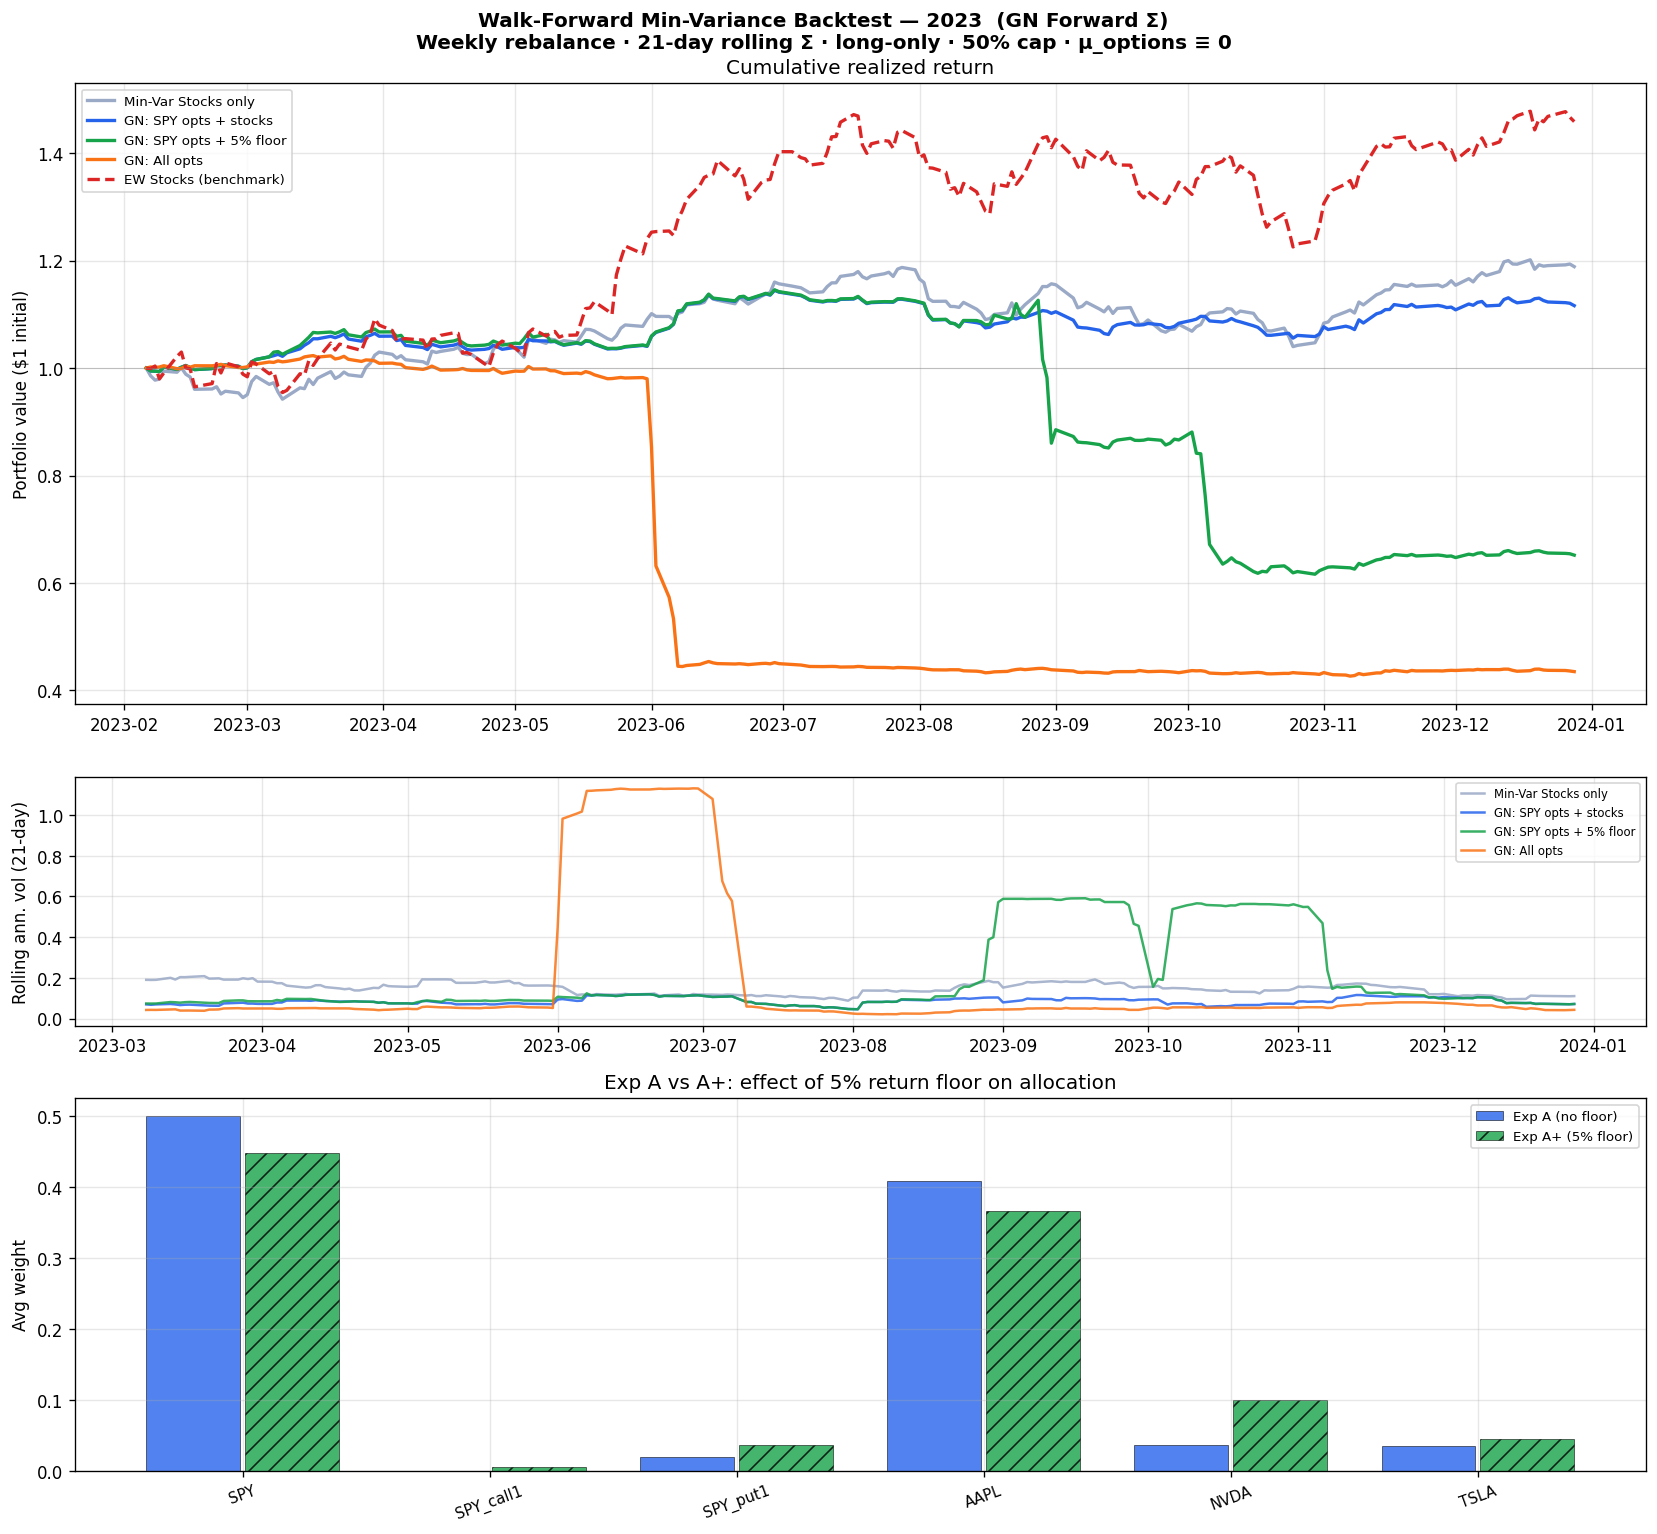


─── Performance Summary ─────────────────────────────────────────────────
                        Total Ret  Ann Ret Ann Vol    Sharpe   Max DD
label                                                                
Min-Var Stocks only        18.89%   21.59%  15.02%   110.42%  -12.41%
GN: SPY opts + stocks      11.62%   13.23%   8.67%    95.00%   -7.78%
GN: SPY opts + 5% floor   -34.81%  -38.34%  27.06%  -160.15%  -46.20%
GN: All opts              -56.49%  -60.95%  37.60%  -175.42%  -58.30%
EW Stocks (benchmark)      45.88%   53.22%  25.06%   192.43%  -16.74%

─── Average weights ──────────────────────────────────────────────────────
  Exp 0 (stocks): SPY=0.500  AAPL=0.480  NVDA=0.016
  Exp A (GN SPY opts): SPY=0.500  AAPL=0.408  NVDA=0.037  TSLA=0.036  SPY_put1=0.019
  Exp A+ (5% floor): SPY=0.447  AAPL=0.366  NVDA=0.100  TSLA=0.045  SPY_put1=0.037  SPY_call1=0.005
  Exp B (GN all opts): SPY=0.484  AAPL=0.321  NVDA=0.092  TSLA=0.059  TSLA_put1=0.018  SPY_put1=0.010  AAPL_put1=0.009  NV

/var/folders/v7/fy28j8pd6yb_vb5vddcfccd00000gn/T/ipykernel_29210/4200173853.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .applymap(lambda x: f"{x:.2%}" if abs(x) <= 5 else f"{x:.3f}")


In [115]:
# ── Asset universes ───────────────────────────────────────────────────────────
_UNIV_STOCKS = _SYMS
_UNIV_A      = ["SPY", "SPY_call1", "SPY_put1", "AAPL", "NVDA", "TSLA"]
_UNIV_B      = [f"{s}{sfx}" for s in _SYMS for sfx in ["", "_call1", "_put1"]]

# ── Pre-index research panel: symbol → DataFrame indexed by date_t ────────────
_rp_idx = {sym: _rp[_rp["symbol"] == sym].set_index("date_t").sort_index()
           for sym in _SYMS}

# ── Benchmark: equal-weight stocks, static ────────────────────────────────────
_ew_daily = _rets_all[_SYMS].mean(axis=1)
_ew_path  = (1 + _ew_daily.iloc[_LOOKBACK:]).cumprod()
_ew_path  = _ew_path / _ew_path.iloc[0]
_ew_path.name = "EW Stocks (benchmark)"

# ── Exp 0: Stocks only — empirical Σ (baseline, no options data needed) ───────
print("Running Exp 0: Stocks only (empirical Σ) …")
_path0, _wts0 = _wf_minvar(_rets_all, _UNIV_STOCKS, "Min-Var Stocks only")
print(f"  Final value: {_path0.iloc[-1]:.4f}")

# ── Exp A: SPY options + stocks — GN forward-looking Σ ────────────────────────
print("\nRunning Exp A: SPY opts + stocks  [GN Σ, no return floor] …")
_pathA, _wtsA = _wf_gn(
    _rets_all, _UNIV_A, _SYMS, _rp_idx,
    "GN: SPY opts + stocks"
)
print(f"  Final value: {_pathA.iloc[-1]:.4f}")

# ── Exp A+: same + 5 % annualized floor; μ_options ≡ 0 ──────────────────────
print("\nRunning Exp A+: SPY opts + stocks  [GN Σ + 5% min return, μ_opts=0] …")
_pathAp, _wtsAp = _wf_gn(
    _rets_all, _UNIV_A, _SYMS, _rp_idx,
    "GN: SPY opts + 5% floor",
    min_ann_return=0.05,
)
print(f"  Final value: {_pathAp.iloc[-1]:.4f}")

# ── Exp B: all symbols with options — GN Σ ────────────────────────────────────
print("\nRunning Exp B: All opts  [GN Σ] …")
_pathB, _wtsB = _wf_gn(
    _rets_all, _UNIV_B, _SYMS, _rp_idx,
    "GN: All opts"
)
print(f"  Final value: {_pathB.iloc[-1]:.4f}")

# ── Align all paths to a common start ────────────────────────────────────────
_all_raw   = [_path0, _pathA, _pathAp, _pathB, _ew_path]
_start_dt  = max(p.index.min() for p in _all_raw)
_paths     = [p.loc[_start_dt:] / float(p.loc[_start_dt]) for p in _all_raw]

PORT_COLORS5 = ["#9aa9c6", "#2563eb", "#16a34a", "#f97316", "#dc2626"]

fig, axes = plt.subplots(3, 1, figsize=(14, 13),
                          gridspec_kw={"height_ratios": [2.5, 1, 1.5]})
fig.suptitle(
    "Walk-Forward Min-Variance Backtest — 2023  (GN Forward Σ)\n"
    "Weekly rebalance · 21-day rolling Σ · long-only · 50% cap · μ_options ≡ 0",
    fontsize=12, fontweight="bold"
)

# Panel 1: cumulative value
ax = axes[0]
for path, col in zip(_paths, PORT_COLORS5):
    ls = "--" if "benchmark" in path.name.lower() else "-"
    ax.plot(path.index, path.values, lw=2.0, color=col, ls=ls, label=path.name)
ax.axhline(1.0, color="gray", lw=0.6, alpha=0.4)
ax.set_ylabel("Portfolio value ($1 initial)")
ax.set_title("Cumulative realized return")
ax.legend(fontsize=8)

# Panel 2: rolling 21-day realized vol
ax = axes[1]
for path, col in zip(_paths[:4], PORT_COLORS5):
    r = path.pct_change().dropna()
    ax.plot(r.rolling(21).std().mul(np.sqrt(252)).index,
            r.rolling(21).std().mul(np.sqrt(252)).values,
            lw=1.5, color=col, alpha=0.85, label=path.name)
ax.set_ylabel("Rolling ann. vol (21-day)")
ax.legend(fontsize=7)

# Panel 3: avg weights for Exp A vs A+ (shows effect of return floor)
ax = axes[2]
for wts_df, lbl, col, hatch in [(_wtsA,  "Exp A (no floor)",  "#2563eb", ""),
                                  (_wtsAp, "Exp A+ (5% floor)", "#16a34a", "//")]:
    if wts_df.empty:
        continue
    mean_w = wts_df.mean().reindex(_UNIV_A).fillna(0)
    x_pos  = np.arange(len(_UNIV_A))
    offset = -0.2 if hatch == "" else 0.2
    ax.bar(x_pos + offset, mean_w.values, 0.38, color=col, alpha=0.8,
           hatch=hatch, edgecolor="k", lw=0.4, label=lbl)
ax.set_xticks(np.arange(len(_UNIV_A)))
ax.set_xticklabels(_UNIV_A, rotation=20, fontsize=9)
ax.set_ylabel("Avg weight")
ax.set_title("Exp A vs A+: effect of 5% return floor on allocation")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Performance summary table ─────────────────────────────────────────────────
_stats_rows = [_port_stats(p, p.name) for p in _paths]
_stats_df   = pd.DataFrame(_stats_rows).set_index("label")

print("\n─── Performance Summary ─────────────────────────────────────────────────")
print(_stats_df[["total_return","ann_return","ann_vol","sharpe","max_dd"]]
      .rename(columns={"total_return":"Total Ret","ann_return":"Ann Ret",
                        "ann_vol":"Ann Vol","sharpe":"Sharpe","max_dd":"Max DD"})
      .applymap(lambda x: f"{x:.2%}" if abs(x) <= 5 else f"{x:.3f}")
      .to_string())

# ── Avg weights per experiment ────────────────────────────────────────────────
print("\n─── Average weights ──────────────────────────────────────────────────────")
for wts_df, lbl in [(_wts0,"Exp 0 (stocks)"),(_wtsA,"Exp A (GN SPY opts)"),
                     (_wtsAp,"Exp A+ (5% floor)"),(_wtsB,"Exp B (GN all opts)")]:
    if wts_df.empty:
        continue
    mw  = wts_df.mean().sort_values(ascending=False)
    mw  = mw[mw > 0.005]
    row = "  ".join(f"{c}={v:.3f}" for c, v in mw.items())
    print(f"  {lbl}: {row}")

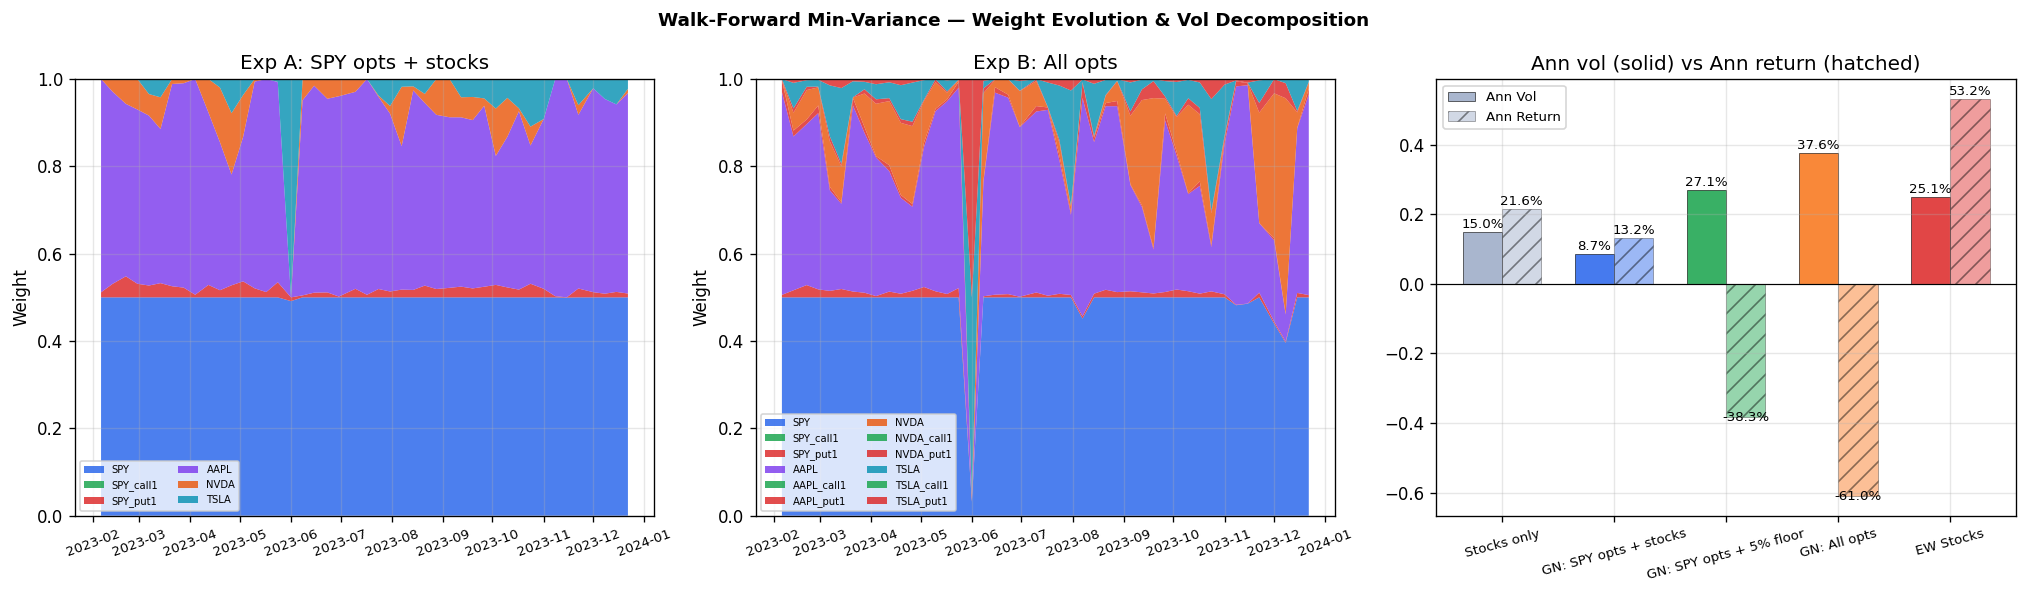


─── Realized daily-return covariance (diagonal = variance) ─────────────
                        Min-Var Stocks only GN: SPY opts + stocks GN: SPY opts + 5% floor
Min-Var Stocks only                  0.0226                0.0082                  0.0030
GN: SPY opts + stocks                0.0082                0.0075                  0.0091
GN: SPY opts + 5% floor              0.0030                0.0091                  0.0732


/var/folders/v7/fy28j8pd6yb_vb5vddcfccd00000gn/T/ipykernel_29210/1124864430.py:70: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(_realized_cov.applymap(lambda x: f"{x:.4f}").to_string())


In [116]:
# ── Detailed view: weight over time + per-experiment vol reduction ────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Walk-Forward Min-Variance — Weight Evolution & Vol Decomposition",
             fontsize=11, fontweight="bold")

# Panel 1 & 2: weight stacks for Exp A and Exp B
for ax, wts_df, lbl, univ in [
    (axes[0], _wtsA, "Exp A: SPY opts + stocks", _UNIV_A),
    (axes[1], _wtsB, "Exp B: All opts",           _UNIV_B),
]:
    if wts_df.empty:
        ax.text(0.5, 0.5, "No weights", ha="center", va="center", transform=ax.transAxes)
        continue
    # align columns, fill missing with 0
    plot_cols = [c for c in univ if c in wts_df.columns]
    wts_plot  = wts_df[plot_cols].fillna(0.0)
    # color: blue=underlying, green=call, red=put
    c_map = {"call": "#16a34a", "put": "#dc2626"}
    colors_s = []
    base_colors = ["#2563eb","#7c3aed","#ea580c","#0891b2"]
    sym_idx = {s: i for i, s in enumerate(_SYMS)}
    for col in plot_cols:
        if "_call" in col:   colors_s.append(c_map["call"])
        elif "_put" in col:  colors_s.append(c_map["put"])
        else:
            i = sym_idx.get(col, 0)
            colors_s.append(base_colors[i % len(base_colors)])

    ax.stackplot(wts_plot.index, *[wts_plot[c] for c in plot_cols],
                 labels=plot_cols, colors=colors_s, alpha=0.82)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Weight")
    ax.set_title(lbl)
    ax.legend(fontsize=6, loc="lower left", ncol=2)
    ax.tick_params(axis="x", labelrotation=20, labelsize=8)

# Panel 3: annualized vol and return bar comparison
ax = axes[2]
_labels_bar = [r["label"].replace("Min-Var ","").replace(" (benchmark)","")
               for r in _stats_rows]
_vols_bar   = [r["ann_vol"]    for r in _stats_rows]
_rets_bar   = [r["ann_return"] for r in _stats_rows]

x_b = np.arange(len(_labels_bar))
w_b = 0.35
bars_v = ax.bar(x_b - w_b/2, _vols_bar, w_b, color=PORT_COLORS5, alpha=0.85,
                label="Ann Vol", edgecolor="k", lw=0.4)
bars_r = ax.bar(x_b + w_b/2, _rets_bar, w_b, color=PORT_COLORS5, alpha=0.45,
                label="Ann Return", edgecolor="k", lw=0.4, hatch="//")
for bar, v in zip(bars_v, _vols_bar):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
            f"{v:.1%}", ha="center", va="bottom", fontsize=8)
for bar, v in zip(bars_r, _rets_bar):
    ypos = v + 0.003 if v >= 0 else v - 0.02
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f"{v:.1%}", ha="center", va="bottom", fontsize=8)
ax.axhline(0, color="black", lw=0.7)
ax.set_xticks(x_b)
ax.set_xticklabels(_labels_bar, rotation=15, fontsize=8)
ax.set_title("Ann vol (solid) vs Ann return (hatched)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Realized covariance reduction check ──────────────────────────────────────
print("\n─── Realized daily-return covariance (diagonal = variance) ─────────────")
_path_matrix = pd.concat([p.pct_change().rename(p.name) for p in _paths[:3]], axis=1).dropna()
_realized_cov = _path_matrix.cov() * 252
print(_realized_cov.applymap(lambda x: f"{x:.4f}").to_string())

## 5.1  Problem Formulation, Covariance Construction, and KKT Conditions

---

### Distribution Fitted at Each Rebalance Date

At every rebalance date $t$, for each symbol $s \in \{\text{SPY, AAPL, NVDA, TSLA}\}$ we fit a **log-normal risk-neutral distribution** to the 4 panel option contracts (2 ATM calls, 2 ATM puts).

**Assumed terminal-price model:**

$$S_T \mid \theta \;\sim\; \text{LogNormal}\!\left(\ln S_0 + \bigl(\mu - \tfrac{\sigma^2}{2}\bigr)T,\;\sigma^2 T\right), \qquad \theta = [\mu,\,\sigma]^\top$$

**Step 1 – Gauss-Newton / DNLP calibration.**  Minimise residuals to 4 observed option mid-prices $\{m_i\}$:

$$\hat\theta = \arg\min_\theta \sum_{i=1}^{4}\bigl[C_i(\theta) - m_i\bigr]^2$$

Each iteration linearises $C_i$ around the current iterate and solves a CVXPY QP (Levenberg–Marquardt):

$$\min_{\delta\theta}\; \bigl\lVert J^{(k)}\,\delta\theta + r^{(k)} \bigr\rVert_2^2 \;+\; \lambda^{(k)}\,\lVert\delta\theta\rVert_2^2$$

where $J^{(k)}$ is the numerical Jacobian of $(C_1,\ldots,C_4)$ w.r.t.\ $\theta$, $r^{(k)}$ is the current residual vector, and $\lambda^{(k)}$ is the adaptive LM damping.

**Step 2 – Parameter uncertainty (Fisher covariance):**

$$\Sigma_\theta \;\approx\; \widehat{\text{MSE}}\cdot(J^\top J)^{-1}$$

Sample $n_\text{param}=300$ draws: $\;\theta^{(k)} \sim \mathcal{N}\!\left([\hat\mu,\hat\sigma]^\top,\,\Sigma_\theta\right)$.

**Step 3 – Forward-looking covariance via Monte Carlo.** For each draw simulate $n_\text{MC}=6{,}000$ terminal prices $S_T^{(k,\ell)}$ and compute period returns:

$$R_\text{und} = \frac{S_T - S_0}{S_0}, \qquad R_\text{call} = \frac{(S_T - K_c)^+ - C_0}{C_0}, \qquad R_\text{put} = \frac{(K_p - S_T)^+ - P_0}{P_0}$$

The $3\times 3$ **per-symbol daily covariance block** is:

$$\Sigma^{(s)} = \frac{1}{T\cdot 252}\,\operatorname{Cov}\!\bigl[R_\text{und},\,R_\text{call},\,R_\text{put}\bigr]_{\text{MC}}$$

---

### Full Cross-Asset Covariance Matrix

The $N\times N$ matrix $\Sigma_t$ (with $N = n_\text{syms}\times 3$ assets) is assembled as follows.  Let $s_i$ be the symbol and $t_i\in\{0,1,2\}$ the asset type (underlying / call / put) of asset $i$:

$$\Sigma_{ij} = \begin{cases} \Sigma^{(s_i)}_{t_i,\,t_j} & s_i = s_j \quad\text{(GN Monte-Carlo block)} \\[4pt] \tilde\beta_i\;\rho^{\text{und}}_{s_i s_j}\;\tilde\beta_j\;\sqrt{\Sigma^{(s_i)}_{00}\,\Sigma^{(s_j)}_{00}} & s_i \neq s_j \quad\text{(structural cross-asset)} \end{cases}$$

where $\rho^{\text{und}}_{s_i s_j}$ is the rolling 21-day empirical correlation between underlying returns and:

$$\tilde\beta_k = \begin{cases} 1 & t_k = 0\;\text{(underlying)} \\ \dfrac{\Sigma^{(s_k)}_{t_k,\,0}}{\Sigma^{(s_k)}_{00}} & t_k \in\{1,2\}\;\text{(return-space loading of option on its underlying)} \end{cases}$$

A small Tikhonov ridge $\epsilon I$ ($\epsilon=10^{-7}$) ensures positive definiteness.

---

### Minimum-Variance Optimization Problem

$$\boxed{\min_{w \in \mathbb{R}^n}\;\; w^\top \Sigma_t\, w}$$

subject to:

| Constraint | Description |
|:---|:---|
| $\mathbf{1}^\top w = 1$ | Fully invested |
| $w \geq \mathbf{0}$ | Long-only |
| $w_i \leq 0.5\;\forall i$ | Concentration cap |
| $\bar\mu_\text{daily}^\top w \geq r_\text{floor}/252$ | Return floor (Exp A+ only; $\bar\mu_\text{options}\equiv 0$) |

For Exp 0 (stocks only) the covariance is rolling **empirical** $\hat\Sigma$ instead of the GN forward-looking matrix.

---

### KKT Conditions

Introduce dual variables $\nu\in\mathbb{R}$ (equality), $\lambda\geq 0$ (lower bound), $\gamma\geq 0$ (upper bound), $\theta\geq 0$ (return floor).  The Lagrangian is:

$$\mathcal{L} = w^\top\Sigma w \;-\; \nu\!\left(\mathbf{1}^\top w-1\right) \;-\; \lambda^\top w \;+\; \gamma^\top\!(w - 0.5\cdot\mathbf{1}) \;-\; \theta\!\left(\bar\mu^\top w - \tfrac{r_\text{floor}}{252}\right)$$

**Stationarity** ($\nabla_w \mathcal{L}=0$):

$$2\,\Sigma w^* \;=\; \nu^*\mathbf{1} + \lambda^* - \gamma^* + \theta^*\bar\mu$$

**Primal feasibility:**

$$\mathbf{1}^\top w^* = 1, \quad w^*\geq\mathbf{0}, \quad w^*\leq 0.5\cdot\mathbf{1}, \quad \bar\mu^\top w^*\geq r_\text{floor}/252$$

**Dual feasibility:** $\quad\lambda^*\geq\mathbf{0},\quad\gamma^*\geq\mathbf{0},\quad\theta^*\geq 0$

**Complementary slackness:**

$$\lambda^*_i\,w^*_i = 0, \qquad \gamma^*_i\,(w^*_i - 0.5) = 0, \qquad \theta^*\!\left(\bar\mu^\top w^*-\tfrac{r_\text{floor}}{252}\right)=0$$

For any **interior** asset $i$ (i.e., $0 < w^*_i < 0.5$) both $\lambda^*_i = \gamma^*_i = 0$, so stationarity simplifies to:

$$2\,(\Sigma w^*)_i \;=\; \nu^* + \theta^*\bar\mu_i$$

Every active asset contributes **equal marginal variance** (adjusted by the return-floor shadow price $\theta^*\bar\mu_i$). Assets at zero weight have excess marginal variance; assets at the cap have the smallest marginal variance.


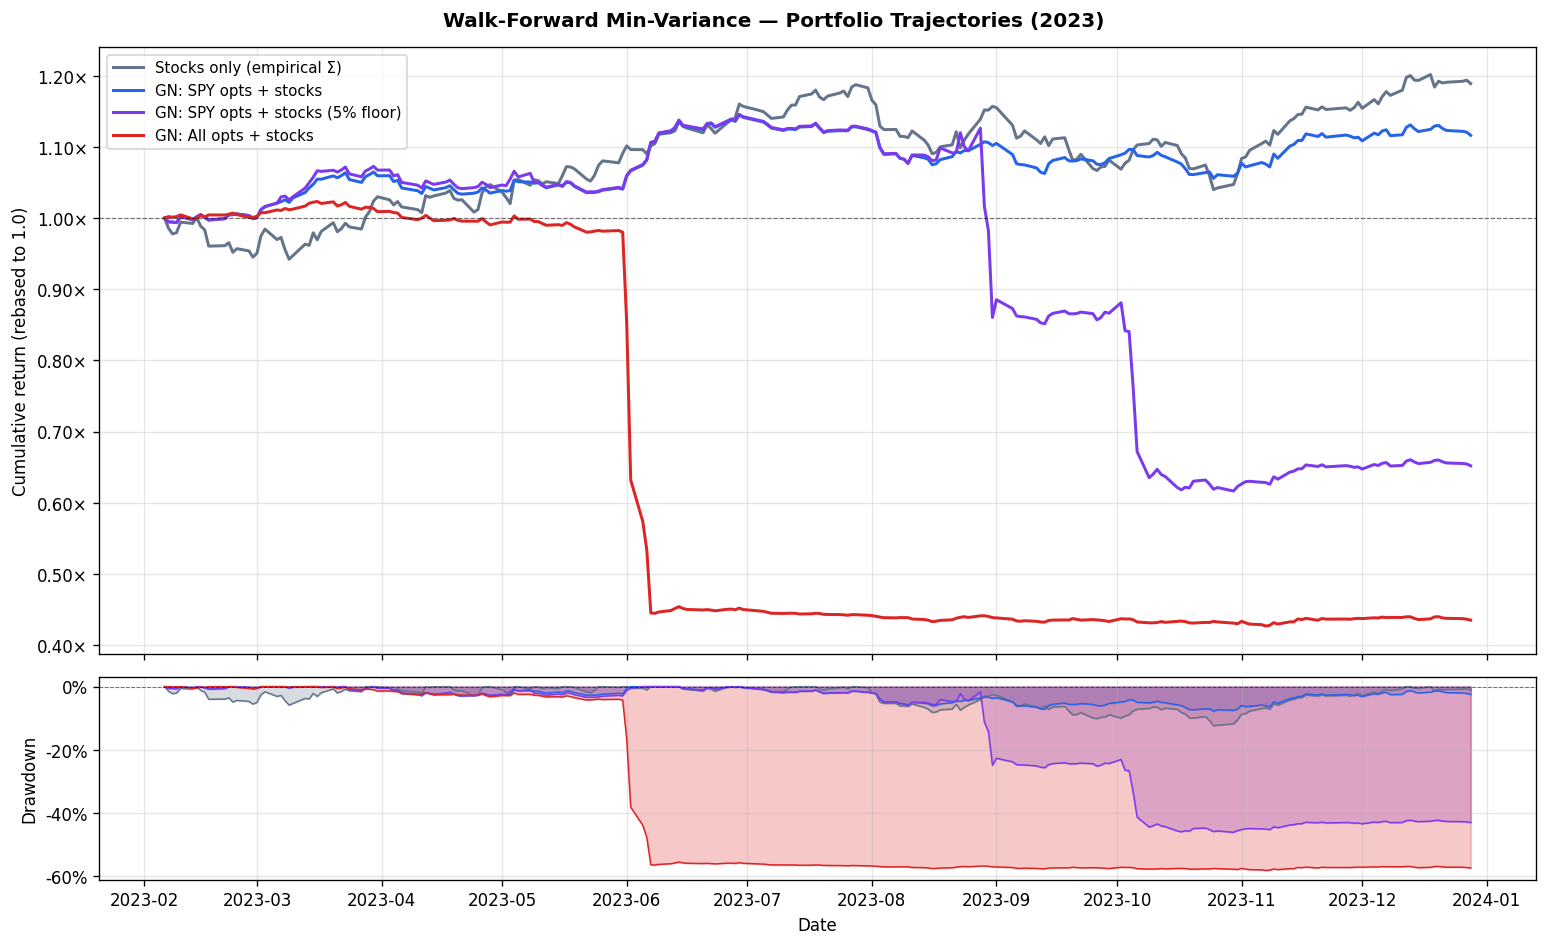

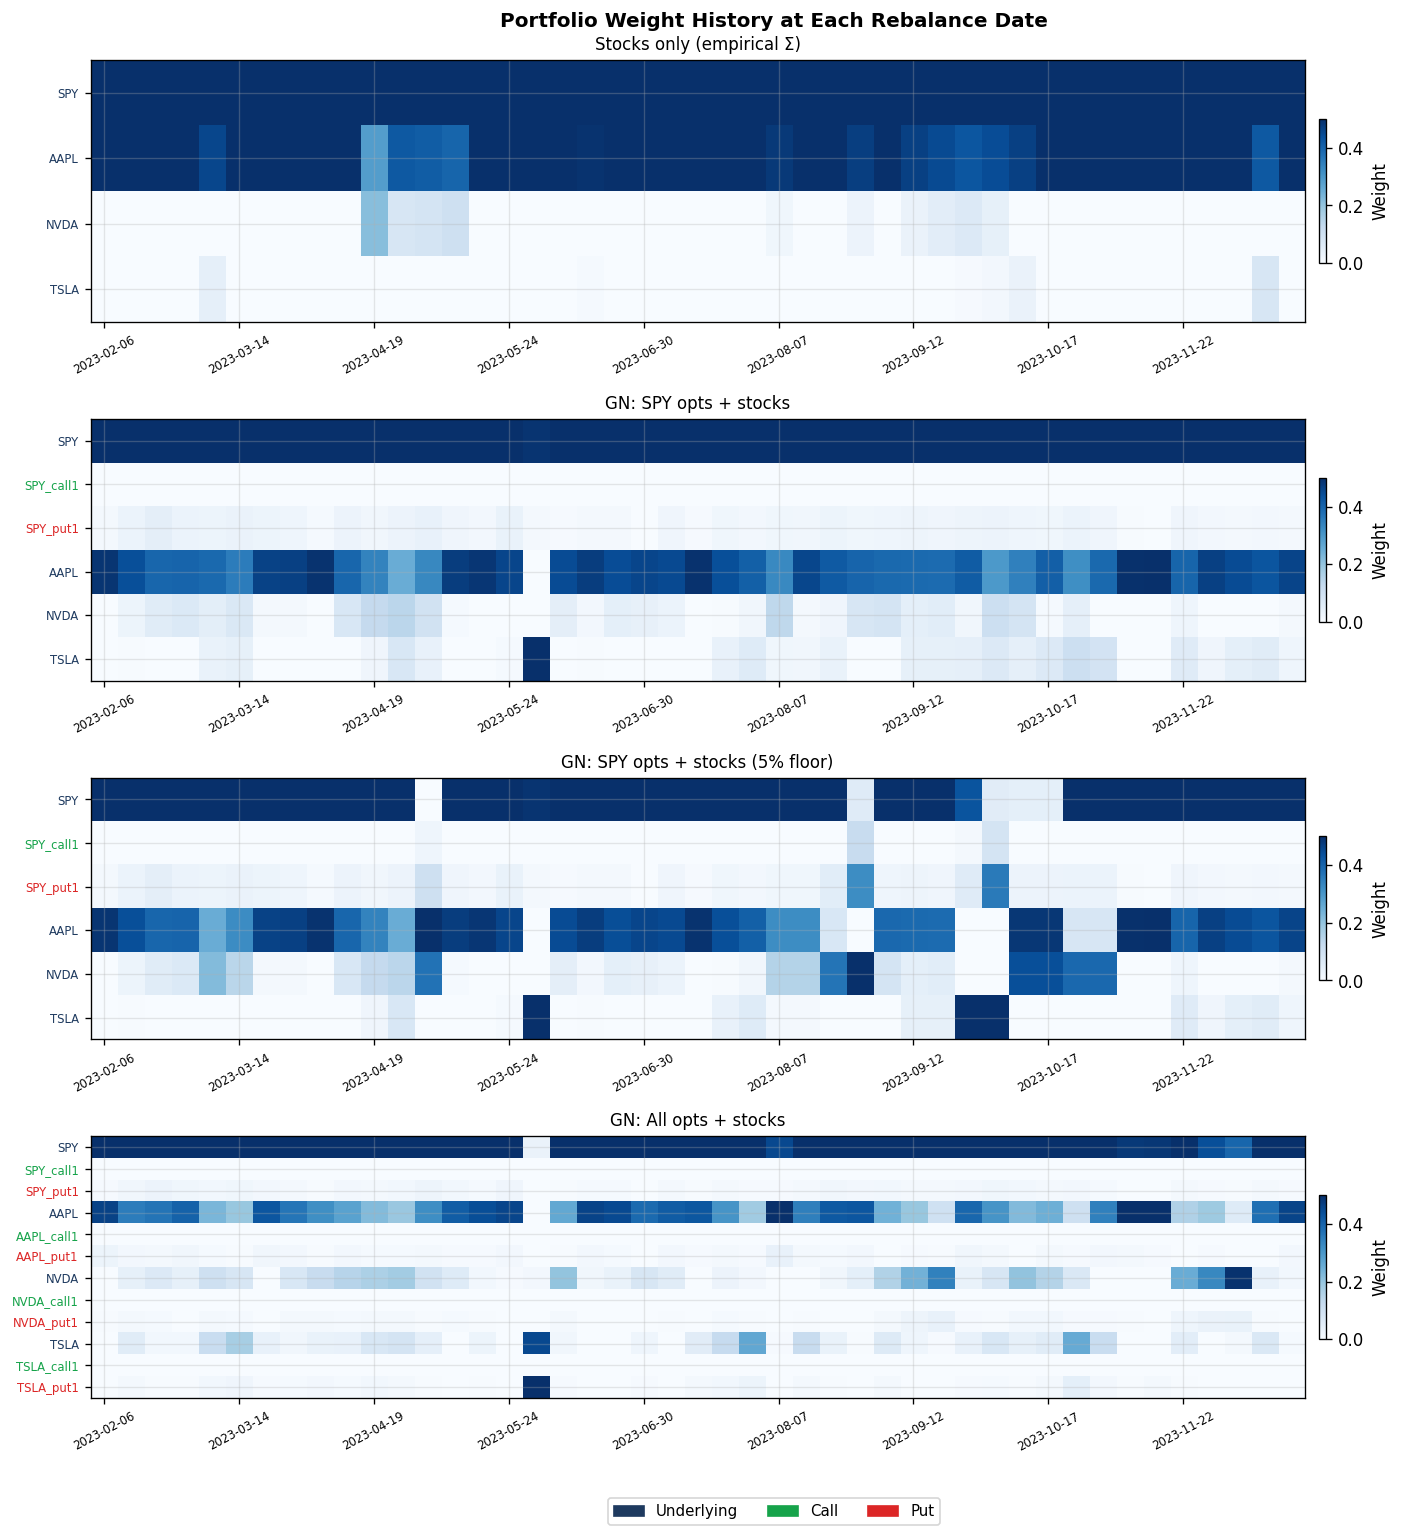

In [117]:
# ── § 5.2  Portfolio trajectories, drawdown, and weight history ─────────────
import matplotlib.ticker as _mtick
import matplotlib.gridspec as _mgs

# Collect all four portfolios ── guard for experiments that may not have run
_all_exps = []
for _path, _wdf, _lbl, _univ in [
    (globals().get("_paths",    [pd.Series(dtype=float)] * 4)[0], globals().get("_wts0",  pd.DataFrame()), "Stocks only (empirical Σ)",       globals().get("_UNIV_STOCKS", [])),
    (globals().get("_paths",    [pd.Series(dtype=float)] * 4)[1], globals().get("_wtsA",  pd.DataFrame()), "GN: SPY opts + stocks",            globals().get("_UNIV_A",      [])),
    (globals().get("_paths",    [pd.Series(dtype=float)] * 4)[2], globals().get("_wtsAp", pd.DataFrame()), "GN: SPY opts + stocks (5% floor)", globals().get("_UNIV_A",      [])),
    (globals().get("_paths",    [pd.Series(dtype=float)] * 4)[3], globals().get("_wtsB",  pd.DataFrame()), "GN: All opts + stocks",            globals().get("_UNIV_B",      [])),
]:
    if not isinstance(_path, pd.Series) or _path.empty:
        continue
    _all_exps.append((_path, _wdf, _lbl, _univ))

_PAL = ["#64748b", "#2563eb", "#7c3aed", "#dc2626"][:len(_all_exps)]

# ══════════════════════════════════════════════════════════════════════
#  Figure 1: Cumulative returns + rolling drawdown
# ══════════════════════════════════════════════════════════════════════
_fig1, (_ax_traj, _ax_dd) = plt.subplots(
    2, 1, figsize=(13, 8), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)
_fig1.suptitle("Walk-Forward Min-Variance — Portfolio Trajectories (2023)",
               fontsize=12, fontweight="bold")

for (_path, _, _lbl, _), _col in zip(_all_exps, _PAL):
    _reb = _path / _path.iloc[0]
    _ax_traj.plot(_reb.index, _reb.values, label=_lbl, color=_col, lw=1.8)
    _dd = (_reb / _reb.cummax()) - 1
    _ax_dd.fill_between(_dd.index, _dd.values, 0, color=_col, alpha=0.25)
    _ax_dd.plot(_dd.index, _dd.values, color=_col, lw=0.9)

_ax_traj.axhline(1.0, color="k", lw=0.7, ls="--", alpha=0.5)
_ax_traj.set_ylabel("Cumulative return (rebased to 1.0)")
_ax_traj.yaxis.set_major_formatter(_mtick.FuncFormatter(lambda y, _: f"{y:.2f}×"))
_ax_traj.legend(fontsize=9, loc="upper left")
_ax_traj.grid(axis="y", alpha=0.3)

_ax_dd.axhline(0, color="k", lw=0.6, ls="--", alpha=0.5)
_ax_dd.set_ylabel("Drawdown")
_ax_dd.set_xlabel("Date")
_ax_dd.yaxis.set_major_formatter(_mtick.FuncFormatter(lambda y, _: f"{y:.0%}"))
_ax_dd.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════
#  Figure 2: Weight history — one heatmap row per experiment
# ══════════════════════════════════════════════════════════════════════
_n_exp = len(_all_exps)
_fig2, _axs2 = plt.subplots(_n_exp, 1, figsize=(13, 3.2 * _n_exp), squeeze=False)
_fig2.suptitle("Portfolio Weight History at Each Rebalance Date",
               fontsize=12, fontweight="bold")

for _ax_row, (_path, _wdf, _lbl, _univ) in zip(_axs2[:, 0], _all_exps):
    if _wdf.empty:
        _ax_row.text(0.5, 0.5, "No weight history", ha="center", va="center",
                     transform=_ax_row.transAxes)
        _ax_row.set_title(_lbl, fontsize=10)
        continue

    _cols_plot = [c for c in _univ if c in _wdf.columns]
    if not _cols_plot:
        _cols_plot = list(_wdf.columns)

    _mat = _wdf[_cols_plot].fillna(0.0).T          # assets × rebalance-dates
    _im  = _ax_row.imshow(_mat.values, aspect="auto", vmin=0.0, vmax=0.5,
                           cmap="Blues", interpolation="nearest")

    # y-axis: asset names, colour-coded
    _ax_row.set_yticks(range(len(_cols_plot)))
    _yt_colors = []
    for _c in _cols_plot:
        if "_call" in _c:   _yt_colors.append("#16a34a")
        elif "_put" in _c:  _yt_colors.append("#dc2626")
        else:               _yt_colors.append("#1e3a5f")
    _ax_row.set_yticklabels(_cols_plot, fontsize=7)
    for _tick, _tc in zip(_ax_row.get_yticklabels(), _yt_colors):
        _tick.set_color(_tc)

    # x-axis: every ~8th rebalance date label
    _step = max(1, len(_mat.columns) // 8)
    _ax_row.set_xticks(range(0, len(_mat.columns), _step))
    _ax_row.set_xticklabels(
        [str(d)[:10] for d in _mat.columns[::_step]],
        rotation=28, fontsize=7
    )

    _ax_row.set_title(_lbl, fontsize=10)
    _fig2.colorbar(_im, ax=_ax_row, shrink=0.55, pad=0.01, label="Weight")

# Shared legend for asset-type colour coding
from matplotlib.patches import Patch as _Patch
_fig2.legend(
    handles=[_Patch(color="#1e3a5f", label="Underlying"),
             _Patch(color="#16a34a", label="Call"),
             _Patch(color="#dc2626", label="Put")],
    loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.01)
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()
